# 불량 탐지 모델링 및 SHAP 기반 전이 위험 분석

이 노트북은 자동차 제조 4개 공정의 품질 이벤트를 분석합니다. 먼저 공정 이벤트 단위의 **불량 탐지 모델**을 학습하고, 이어서 인접 공정 사이의 불량 전이 가능성을 예측하는 **공정 전이 예측 모델**을 학습합니다.

주요 작업:

- `defect_detection_train.csv`, `defect_detection_test.csv`를 읽어 이벤트 단위 불량 탐지 데이터셋을 구성합니다.
- `event_json` 내부의 센서값, 공정 지표, 설비 상태, 공정별 `processData`를 feature로 펼칩니다.
- 정답 유출 가능성이 큰 검사 결과/라벨성 컬럼을 제거하고, 단일 feature만으로 과도하게 예측되는 컬럼을 추가로 필터링합니다.
- LightGBM, XGBoost, CatBoost, Logistic Regression 후보 모델을 비교합니다.
- 정확도, 정밀도, 재현율, F1, PR-AUC, ROC-AUC, 혼동행렬, PR/ROC 곡선을 출력합니다.
- 인접 공정 전이 예측 모델과 SHAP 중요도를 저장합니다.

**실행 준비**

필요한 Python 패키지를 Colab 런타임에 맞춰 설치합니다. 이미 설치된 환경에서는 바로 넘어갑니다.

In [1]:
import importlib.util
import subprocess
import sys


def ensure_package(import_name: str, pip_name: str | None = None):
    pip_name = pip_name or import_name
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name, "-q"])


ensure_package("pandas")
ensure_package("numpy")
ensure_package("sklearn", "scikit-learn")
ensure_package("lightgbm")
ensure_package("xgboost")
ensure_package("catboost")
ensure_package("shap")
ensure_package("joblib")

**라이브러리 로드**

모델 학습, 평가, 시각화에 필요한 라이브러리를 불러오고 한글 폰트를 설정합니다.

In [2]:
from __future__ import annotations

import json
import shutil
import subprocess
import sys
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import ParameterSampler, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 180)
pd.set_option("display.max_rows", 100)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


KOREAN_FONT_CANDIDATES = [
    "Malgun Gothic",
    "AppleGothic",
    "NanumGothic",
    "NanumBarunGothic",
    "Noto Sans CJK KR",
    "Noto Sans KR",
    "Arial Unicode MS",
]


def find_korean_font() -> str | None:
    available_fonts = {font.name for font in fm.fontManager.ttflist}
    for font_name in KOREAN_FONT_CANDIDATES:
        if font_name in available_fonts:
            return font_name
    return None


def try_install_colab_korean_font() -> str | None:
    if not Path("/content").exists() or shutil.which("apt-get") is None:
        return None
    try:
        subprocess.run(["apt-get", "update", "-qq"], check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        subprocess.run(["apt-get", "install", "-y", "-qq", "fonts-nanum"], check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        for font_path in [
            Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf"),
            Path("/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"),
        ]:
            if font_path.exists():
                fm.fontManager.addfont(str(font_path))
                return fm.FontProperties(fname=str(font_path)).get_name()
    except Exception as exc:
        print("Colab 한글 폰트 설치를 건너뜁니다:", exc)
    return None


def configure_korean_font() -> str | None:
    font_name = find_korean_font() or try_install_colab_korean_font() or find_korean_font()
    if font_name:
        plt.rcParams["font.family"] = font_name
        plt.rcParams["axes.unicode_minus"] = False
        return font_name
    plt.rcParams["axes.unicode_minus"] = False
    return None


KOREAN_FONT_NAME = configure_korean_font()
if KOREAN_FONT_NAME:
    print(f"matplotlib Korean font: {KOREAN_FONT_NAME}")
else:
    print("한글 폰트를 찾지 못했습니다.")

matplotlib Korean font: NanumGothic


**경로 설정**

Colab에서는 Google Drive를 마운트하고, 로컬에서는 프로젝트 내부의 generated CSV를 사용합니다.

In [3]:
# Drive mount
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    print("Colab이 아니므로 Google Drive mount를 건너뜁니다.")

PROJECT_ROOT_CANDIDATES = [
    Path("/content/drive/MyDrive/ai-service"),
    Path("/content/drive/MyDrive"),
    Path.cwd(),
]
PROJECT_ROOT = next((p for p in PROJECT_ROOT_CANDIDATES if (p / "app" / "ml" / "datasets" / "process").exists()), Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROCESS_ROOT = PROJECT_ROOT / "app" / "ml" / "datasets" / "process"
GENERATED_ROOT = Path("/content/drive/MyDrive/aims_dataset/generated") if IN_COLAB else PROCESS_ROOT / "generated"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "defect_transfer" if not IN_COLAB else Path("/content/drive/MyDrive/defect_transfer_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESS_ROOT:", PROCESS_ROOT)
print("GENERATED_ROOT:", GENERATED_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)

Mounted at /content/drive
PROJECT_ROOT: /content
PROCESS_ROOT: /content/app/ml/datasets/process
GENERATED_ROOT: /content/drive/MyDrive/aims_dataset/generated
OUTPUT_DIR: /content/drive/MyDrive/defect_transfer_outputs


## 1. generated 학습 데이터셋 로드

**데이터 준비**

아래 4개 CSV가 필요합니다.

- `defect_detection_train.csv`
- `defect_detection_test.csv`
- `transfer_prediction_train.csv`
- `transfer_prediction_test.csv`

In [4]:
required_files = [
    GENERATED_ROOT / "defect_detection_train.csv",
    GENERATED_ROOT / "defect_detection_test.csv",
    GENERATED_ROOT / "transfer_prediction_train.csv",
    GENERATED_ROOT / "transfer_prediction_test.csv",
]

missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    missing_text = "\n".join(str(path) for path in missing_files)
    raise FileNotFoundError(
        "Colab에서 사용할 generated CSV 파일을 찾을 수 없습니다. "
        "Google Drive의 /content/drive/MyDrive/aims_dataset/generated 폴더에 "
        "아래 파일 4개를 업로드한 뒤 다시 실행하세요.\n"
        f"{missing_text}"
    )

DEFECT_TRAIN_PATH = GENERATED_ROOT / "defect_detection_train.csv"
DEFECT_TEST_PATH = GENERATED_ROOT / "defect_detection_test.csv"
TRANSFER_TRAIN_PATH = GENERATED_ROOT / "transfer_prediction_train.csv"
TRANSFER_TEST_PATH = GENERATED_ROOT / "transfer_prediction_test.csv"

print("generated CSV 4종을 확인했습니다.")
print("defect train:", DEFECT_TRAIN_PATH)
print("defect test:", DEFECT_TEST_PATH)
print("transfer train:", TRANSFER_TRAIN_PATH)
print("transfer test:", TRANSFER_TEST_PATH)

generated CSV 4종을 확인했습니다.
defect train: /content/drive/MyDrive/aims_dataset/generated/defect_detection_train.csv
defect test: /content/drive/MyDrive/aims_dataset/generated/defect_detection_test.csv
transfer train: /content/drive/MyDrive/aims_dataset/generated/transfer_prediction_train.csv
transfer test: /content/drive/MyDrive/aims_dataset/generated/transfer_prediction_test.csv


**데이터 확인**

CSV를 DataFrame으로 읽고 shape와 샘플 행을 확인합니다.

In [5]:
defect_train_raw = pd.read_csv(DEFECT_TRAIN_PATH)
defect_test_raw = pd.read_csv(DEFECT_TEST_PATH)
transfer_train_raw = pd.read_csv(TRANSFER_TRAIN_PATH)
transfer_test_raw = pd.read_csv(TRANSFER_TEST_PATH)

print("defect_train_raw:", defect_train_raw.shape)
print("defect_test_raw:", defect_test_raw.shape)
print("transfer_train_raw:", transfer_train_raw.shape)
print("transfer_test_raw:", transfer_test_raw.shape)
display(defect_train_raw.head(3))
display(transfer_train_raw.head(3))

defect_train_raw: (38400, 19)
defect_test_raw: (9600, 19)
transfer_train_raw: (28800, 16)
transfer_test_raw: (7200, 16)


,raw_event_id,event_id,event_time,car_master_id_raw,equipment_id,process_code_raw,station_code_raw,equipment_code_raw,equipment_type_raw,operation_status_raw,event_type_raw,event_json,is_sent,sent_at,created_at,updated_at,defect_yn,defect_reason,dataset_split
0,1,EVT-20260616-000001,2026-06-16T10:00:00,1,1,PRESS,PRESS_STATION_01,EQ_PRESS_001,HYDRAULIC_PRESS,RUNNING,PROCESS_STATUS,"{""event"": {""eventId"": ""EVT-20260616-000001"", ""...",0,NaN,2026-06-27T14:39:42,2026-06-27T14:39:42,0,normal,train
1,2,EVT-20260616-000002,2026-06-16T10:00:03,1,13,BODY,BODY_STATION_03,EQ_BODY_003,ROBOT_ARM,RUNNING,EQUIPMENT_SENSOR,"{""event"": {""eventId"": ""EVT-20260616-000002"", ""...",0,NaN,2026-06-27T14:39:42,2026-06-27T14:39:42,1,body_robot_vibration,train
2,3,EVT-20260616-000003,2026-06-16T10:00:06,1,24,PAINT,PAINT_STATION_04,EQ_PAINT_004,CAMERA,RUNNING,QUALITY_CHECK,"{""event"": {""eventId"": ""EVT-20260616-000003"", ""...",0,NaN,2026-06-27T14:39:42,2026-06-27T14:39:42,1,paint_vision_or_thermal,train


,car_master_id,source_event_id,target_event_id,source_process_code,target_process_code,source_defect_yn,target_defect_yn,source_cycle_time_sec,source_station_delay_sec,source_queue_length,source_wip_count,source_current_rms_ampere,source_vibration_score,source_thermal_score,source_event_json,dataset_split
0,1,EVT-20260616-000001,EVT-20260616-000002,PRESS,BODY,0,1,47.833,7.833,6,19,1.731425,0.340920,50.922,"{""event"": {""eventId"": ""EVT-20260616-000001"", ""...",train
1,1,EVT-20260616-000002,EVT-20260616-000003,BODY,PAINT,1,1,56.998,4.998,6,18,2.068431,0.369143,51.042,"{""event"": {""eventId"": ""EVT-20260616-000002"", ""...",train
2,1,EVT-20260616-000003,EVT-20260616-000004,PAINT,ASSEMBLY,1,0,69.326,5.326,7,19,1.648970,0.333915,51.621,"{""event"": {""eventId"": ""EVT-20260616-000003"", ""...",train


## 2. eventJson feature 변환

**셀 설명**

CSV의 `event_json` 컬럼을 학습 가능한 feature로 펼칩니다. 정답 컬럼은 별도로 유지하고, 이후 feature 선택 단계에서 유출 가능 컬럼을 제거합니다.

In [6]:
PROCESS_ORDER = ["PRESS", "BODY", "PAINT", "ASSEMBLY"]
TRANSFER_FLOW_ORDER = [("PRESS", "BODY"), ("BODY", "PAINT"), ("PAINT", "ASSEMBLY")]


def get_nested(obj: dict, path: str, default=np.nan):
    cur = obj
    for key in path.split("."):
        if not isinstance(cur, dict) or key not in cur:
            return default
        cur = cur[key]
    return cur


def to_float(value, default=np.nan):
    try:
        if value is None or value == "":
            return default
        return float(value)
    except Exception:
        return default


def to_int(value, default=0):
    try:
        if value is None or value == "":
            return default
        return int(float(value))
    except Exception:
        return default


def sequence_mismatch(expected, actual):
    if pd.isna(expected) or pd.isna(actual):
        return 0
    return int(str(expected).strip() != str(actual).strip())


def flatten_event_row(row: pd.Series) -> dict:
    payload = json.loads(row["event_json"])
    sensor = payload.get("sensor", {}) or {}
    current = sensor.get("current", {}) or {}
    vibration = sensor.get("vibration", {}) or {}
    robot = sensor.get("robotArmVibration", {}) or {}
    thermal = sensor.get("thermal", {}) or {}
    metrics = payload.get("processMetrics", {}) or {}
    equipment = payload.get("equipment", {}) or {}
    status = payload.get("equipmentStatus", {}) or {}
    product = payload.get("product", {}) or {}
    trace = payload.get("sourceTrace", {}) or {}
    process_data = payload.get("processData", {}) or {}
    press = process_data.get("press", {}) or {}
    body = process_data.get("body", {}) or {}
    paint = process_data.get("paint", {}) or {}
    assembly = process_data.get("assembly", {}) or {}
    bands = body.get("frequencyBands", {}) or {}
    band_values = [to_float(v) for v in bands.values()]
    expected_sequence = assembly.get("expectedSequence", np.nan)
    actual_sequence = assembly.get("actualSequence", np.nan)
    return {
        "raw_event_id": row.get("raw_event_id"),
        "event_id": row.get("event_id"),
        "event_time": row.get("event_time"),
        "car_master_id": product.get("carMasterId", row.get("car_master_id_raw")),
        "process_code": row.get("process_code_raw"),
        "station_code": row.get("station_code_raw"),
        "equipment_code": equipment.get("equipmentCode", row.get("equipment_code_raw")),
        "equipment_type": equipment.get("equipmentType", row.get("equipment_type_raw")),
        "operation_status": status.get("operationStatus", row.get("operation_status_raw")),
        "current_rms_ampere": to_float(current.get("rmsAmpere")),
        "current_max_ampere": to_float(current.get("maxAmpere")),
        "current_min_ampere": to_float(current.get("minAmpere")),
        "vibration_acceleration_g": to_float(vibration.get("accelerationG")),
        "vibration_score": to_float(vibration.get("vibrationScore")),
        "vibration_rms": to_float(vibration.get("vibrationRms")),
        "vibration_peak": to_float(vibration.get("vibrationPeak")),
        "robot_axis": robot.get("axis", np.nan),
        "robot_frequency_hz": to_float(robot.get("frequencyHz")),
        "robot_amplitude": to_float(robot.get("amplitude")),
        "robot_vibration_score": to_float(robot.get("vibrationScore")),
        "thermal_score": to_float(thermal.get("thermalScore")),
        "avg_temperature": to_float(thermal.get("avgTemperature")),
        "max_temperature": to_float(thermal.get("maxTemperature")),
        "min_temperature": to_float(thermal.get("minTemperature")),
        "cycle_time_sec": to_float(metrics.get("cycleTimeSec")),
        "waiting_time_sec": to_float(metrics.get("waitingTimeSec")),
        "processing_time_sec": to_float(metrics.get("processingTimeSec")),
        "station_delay_sec": to_float(metrics.get("stationDelaySec")),
        "throughput_per_min": to_float(metrics.get("throughputPerMin")),
        "queue_length": to_float(metrics.get("queueLength")),
        "wip_count": to_float(metrics.get("wipCount")),
        "equipment_idle_time_sec": to_float(metrics.get("equipmentIdleTimeSec")),
        "ford_row_id": to_int(trace.get("fordRowId")),
        "forming_row_id": to_int(trace.get("formingRowId")),
        "robot_arm_vibration_row_id": to_int(trace.get("robotArmVibrationRowId")),
        "machine_vision_row_id": to_int(trace.get("machineVisionRowId")),
        "bosch_id": to_int(trace.get("boschId")),
        "press_count_increase_yn": int(bool(press.get("countIncreaseYn", False))),
        "press_target_cycle_time_sec": to_float(press.get("targetCycleTimeSec")),
        "press_timestamp_delay_sec": to_float(press.get("timestampDelaySec")),
        "body_robot_motion_status": body.get("robotMotionStatus", np.nan),
        "body_robot_operation_mode": body.get("robotOperationMode", np.nan),
        "body_frequency_peak_band": body.get("frequencyPeakBand", np.nan),
        "body_frequency_band_max": float(np.nanmax(band_values)) if band_values else np.nan,
        "body_frequency_band_mean": float(np.nanmean(band_values)) if band_values else np.nan,
        "paint_image_position": paint.get("imagePosition", np.nan),
        "paint_thermal_std_temp": to_float(paint.get("thermalStdTemp")),
        "paint_thickness_value": to_float(paint.get("thicknessValue")),
        "paint_defect_score": to_float(paint.get("defectScore")),
        "paint_vision_label": paint.get("visionLabel", np.nan),
        "paint_surface_quality_score": to_float(paint.get("surfaceQualityScore")),
        "assembly_expected_sequence": expected_sequence,
        "assembly_actual_sequence": actual_sequence,
        "assembly_missing_part_count": to_int(assembly.get("missingPartCount")),
        "assembly_fastening_error_count": to_int(assembly.get("fasteningErrorCount")),
        "assembly_sequence_error_count": to_int(assembly.get("sequenceErrorCount")),
        "assembly_sequence_mismatch_yn": sequence_mismatch(expected_sequence, actual_sequence),
        "defect_yn": int(row["defect_yn"]),
        "defect_reason": row.get("defect_reason", ""),
    }


def flatten_event_df(raw_df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame([flatten_event_row(row) for _, row in raw_df.iterrows()])

defect_train = flatten_event_df(defect_train_raw)
defect_test = flatten_event_df(defect_test_raw)
print(defect_train.shape, defect_test.shape)
display(pd.crosstab(defect_train["process_code"], defect_train["defect_yn"], normalize="index"))
display(defect_train.head())

(38400, 59) (9600, 59)


defect_yn,0,1
process_code,,
ASSEMBLY,0.793438,0.206563
BODY,0.784479,0.215521
PAINT,0.779792,0.220208
PRESS,0.816042,0.183958


,raw_event_id,event_id,event_time,car_master_id,process_code,station_code,equipment_code,equipment_type,operation_status,current_rms_ampere,current_max_ampere,current_min_ampere,vibration_acceleration_g,vibration_score,vibration_rms,vibration_peak,robot_axis,robot_frequency_hz,robot_amplitude,robot_vibration_score,thermal_score,avg_temperature,max_temperature,min_temperature,cycle_time_sec,waiting_time_sec,processing_time_sec,station_delay_sec,throughput_per_min,queue_length,wip_count,equipment_idle_time_sec,ford_row_id,forming_row_id,robot_arm_vibration_row_id,machine_vision_row_id,bosch_id,press_count_increase_yn,press_target_cycle_time_sec,press_timestamp_delay_sec,body_robot_motion_status,body_robot_operation_mode,body_frequency_peak_band,body_frequency_band_max,body_frequency_band_mean,paint_image_position,paint_thermal_std_temp,paint_thickness_value,paint_defect_score,paint_vision_label,paint_surface_quality_score,assembly_expected_sequence,assembly_actual_sequence,assembly_missing_part_count,assembly_fastening_error_count,assembly_sequence_error_count,assembly_sequence_mismatch_yn,defect_yn,defect_reason
0,1,EVT-20260616-000001,2026-06-16T10:00:00,1,PRESS,PRESS_STATION_01,EQ_PRESS_001,HYDRAULIC_PRESS,RUNNING,1.731425,1.895833,1.567017,0.004600,0.340920,1.038794,2.326837,J2,115.002,0.001039,0.340920,50.922,50.922,54.131,42.190,47.833,5.0,42.833,7.833,1.254,6.0,19.0,12.534,1,55644626,1,1,4,1,40.0,7.833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,normal
1,2,EVT-20260616-000002,2026-06-16T10:00:03,1,BODY,BODY_STATION_03,EQ_BODY_003,ROBOT_ARM,RUNNING,2.068431,2.237299,1.899562,0.006392,0.369143,1.125161,2.698745,J3,121.211,0.001125,0.369143,51.042,51.042,54.491,42.534,56.998,7.0,50.998,4.998,1.053,6.0,18.0,7.996,1,55644626,2,2,6,0,NaN,NaN,WARNING,AUTO,1201_1300_HZ,0.002139,0.001434,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,1,body_robot_vibration
2,3,EVT-20260616-000003,2026-06-16T10:00:06,1,PAINT,PAINT_STATION_04,EQ_PAINT_004,CAMERA,RUNNING,1.648970,1.799303,1.498636,0.001800,0.333915,1.038794,2.326837,J4,113.461,0.001039,0.333915,51.621,51.621,54.021,42.860,69.326,9.0,62.326,5.326,0.865,7.0,19.0,8.521,1,55644626,3,3,7,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LEFT,2.988,118.12,0.48,DEFECT,84.958,NaN,NaN,0,0,0,0,1,paint_vision_or_thermal
3,4,EVT-20260616-000004,2026-06-16T10:00:09,1,ASSEMBLY,ASSEMBLY_STATION_04,EQ_ASSEMBLY_004,CONVEYOR,RUNNING,1.931789,2.104463,1.759116,0.000400,0.361150,1.038794,2.326837,J5,119.453,0.001039,0.361150,51.392,51.392,53.519,43.202,59.200,8.0,51.200,1.200,1.014,6.0,17.0,1.920,1,55644626,4,4,9,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A01>A02>A03>A04,A01>A02>A03>A04,0,0,0,0,0,normal
4,5,EVT-20260616-000005,2026-06-16T10:00:12,2,PRESS,PRESS_STATION_04,EQ_PRESS_004,HYDRAULIC_PRESS,RUNNING,1.724910,1.876135,1.573685,0.001000,0.321575,1.038794,2.326837,J6,110.746,0.001039,0.321575,51.121,51.121,53.927,42.551,44.494,6.0,39.494,4.494,1.348,9.0,20.0,7.191,1,55644630,5,5,11,1,40.0,4.494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,normal


## 3. 모델 학습/평가 helper 함수

**셀 설명**

전처리, class imbalance 보정, threshold 탐색, 혼동행렬, PR/ROC 곡선, feature leakage 점검, 피처 중요도와 데이터 분포 시각화 함수를 정의합니다.

In [7]:
CONFUSION_INDEX = ["실제 정상(0)", "실제 불량(1)"]
CONFUSION_COLUMNS = ["예측 정상(0)", "예측 불량(1)"]
CLASS_NAMES = ["정상", "불량"]
METRIC_LABELS = {
    "accuracy": "정확도",
    "precision": "정밀도",
    "recall": "재현율",
    "f1": "F1 Score",
    "pr_auc": "PR-AUC",
    "roc_auc": "ROC-AUC",
}


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=10)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def split_feature_types(df: pd.DataFrame, feature_cols: list[str]):
    numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
    categorical_cols = [c for c in feature_cols if c not in numeric_cols]
    return numeric_cols, categorical_cols


def make_preprocessor(df: pd.DataFrame, feature_cols: list[str], scale_numeric: bool = False):
    numeric_cols, categorical_cols = split_feature_types(df, feature_cols)
    transformers = []
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
    if numeric_cols:
        transformers.append(("num", Pipeline(numeric_steps), numeric_cols))
    if categorical_cols:
        transformers.append(("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", make_one_hot_encoder())]), categorical_cols))
    return ColumnTransformer(transformers=transformers, remainder="drop", verbose_feature_names_out=False)


def scale_pos_weight_for(y):
    y = pd.Series(y).astype(int)
    return float((y == 0).sum() / max((y == 1).sum(), 1))


def predict_positive_proba(estimator, X):
    return estimator.predict_proba(X)[:, 1]


def find_recall_priority_threshold(y_true, proba, min_recall=0.70, min_precision=0.20, beta=2.0):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    if len(thresholds) == 0:
        return 0.5
    precision = precision[:-1]
    recall = recall[:-1]
    beta_sq = beta ** 2
    f_beta = (1 + beta_sq) * precision * recall / np.maximum(beta_sq * precision + recall, 1e-12)
    valid = (recall >= min_recall) & (precision >= min_precision)
    if valid.any():
        valid_idx = np.where(valid)[0]
        best_idx = valid_idx[int(np.nanargmax(f_beta[valid_idx]))]
        return float(thresholds[best_idx])
    return float(thresholds[int(np.nanargmax(f_beta))])

def compute_metrics(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "pr_auc": float(average_precision_score(y_true, proba)),
        "roc_auc": float(roc_auc_score(y_true, proba)),
        "accuracy": float(accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "false_positive_rate": float(fp / max(fp + tn, 1)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


def metric_summary_table(metrics: dict) -> pd.DataFrame:
    return pd.DataFrame([
        ("정확도(Accuracy)", metrics["accuracy"]),
        ("정밀도(Precision)", metrics["precision"]),
        ("재현율(Recall)", metrics["recall"]),
        ("F1 Score", metrics["f1"]),
        ("ROC-AUC", metrics["roc_auc"]),
        ("PR-AUC", metrics["pr_auc"]),
        ("오탐률(False Positive Rate)", metrics["false_positive_rate"]),
        ("임계값(Threshold)", metrics["threshold"]),
    ], columns=["지표", "값"])


def confusion_matrix_table(metrics: dict) -> pd.DataFrame:
    return pd.DataFrame(
        [[metrics["tn"], metrics["fp"]], [metrics["fn"], metrics["tp"]]],
        index=CONFUSION_INDEX,
        columns=CONFUSION_COLUMNS,
    )


def display_confusion_matrix_report(y_true, proba, threshold, title):
    metrics = compute_metrics(y_true, proba, threshold)
    cm_table = confusion_matrix_table(metrics)
    metric_table = metric_summary_table(metrics)
    print(f"재현율(Recall): {metrics['recall']:.4f}")
    print(f"정밀도(Precision): {metrics['precision']:.4f}")
    print(f"F1 Score: {metrics['f1']:.4f}")
    print(f"PR-AUC: {metrics['pr_auc']:.4f}")
    print(f"임계값(Threshold): {metrics['threshold']:.4f}")
    display(metric_table)
    display(cm_table)
    plt.figure(figsize=(4.8, 4.0))
    ax = sns.heatmap(cm_table, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 11})
    ax.set_title(title)
    ax.set_xlabel("예측값")
    ax.set_ylabel("실제값")
    plt.tight_layout()
    plt.show()
    return metric_table, cm_table


def plot_train_test_confusion(y_train, train_proba, y_test, test_proba, threshold, title_prefix):
    train_metrics = compute_metrics(y_train, train_proba, threshold)
    test_metrics = compute_metrics(y_test, test_proba, threshold)
    tables = {
        "Train": confusion_matrix_table(train_metrics),
        "Test": confusion_matrix_table(test_metrics),
    }
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
    for ax, (split_name, cm_table) in zip(axes, tables.items()):
        sns.heatmap(cm_table, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax, annot_kws={"size": 11})
        ax.set_title(f"{title_prefix} {split_name} 혼동행렬")
        ax.set_xlabel("예측값")
        ax.set_ylabel("실제값")
    plt.tight_layout()
    plt.show()
    return train_metrics, test_metrics


def plot_train_test_metric_comparison(train_metrics: dict, test_metrics: dict, title: str):
    rows = []
    for metric_key in ["accuracy", "precision", "recall", "f1", "pr_auc", "roc_auc"]:
        rows.append({"split": "Train", "metric": METRIC_LABELS[metric_key], "value": train_metrics[metric_key]})
        rows.append({"split": "Test", "metric": METRIC_LABELS[metric_key], "value": test_metrics[metric_key]})
    plot_df = pd.DataFrame(rows)
    plt.figure(figsize=(10, 4.5))
    ax = sns.barplot(data=plot_df, x="metric", y="value", hue="split", palette=["#4C78A8", "#F28E2B"])
    ax.set_title(title)
    ax.set_xlabel("평가 지표")
    ax.set_ylabel("값")
    ax.set_ylim(0, 1.05)
    ax.legend(title="데이터")
    plt.tight_layout()
    plt.show()
    display(plot_df.pivot(index="metric", columns="split", values="value").reset_index())


def plot_pr_roc_curves(y_true, proba_by_model: dict[str, np.ndarray], title_prefix: str):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for model_name, proba in proba_by_model.items():
        precision, recall, _ = precision_recall_curve(y_true, proba)
        fpr, tpr, _ = roc_curve(y_true, proba)
        axes[0].plot(recall, precision, label=f"{model_name} (AP={average_precision_score(y_true, proba):.3f})")
        axes[1].plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc_score(y_true, proba):.3f})")
    axes[0].set_title(f"{title_prefix} PR 곡선")
    axes[0].set_xlabel("재현율")
    axes[0].set_ylabel("정밀도")
    axes[0].legend()
    axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    axes[1].set_title(f"{title_prefix} ROC 곡선")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def plot_probability_distribution(y_true, proba, threshold, title):
    plot_df = pd.DataFrame({"actual": pd.Series(y_true).map({0: "정상", 1: "불량"}), "probability": proba})
    plt.figure(figsize=(9, 4.5))
    ax = sns.histplot(data=plot_df, x="probability", hue="actual", bins=30, kde=True, stat="density", common_norm=False)
    ax.axvline(threshold, color="#D62728", linestyle="--", linewidth=1.5, label=f"Threshold={threshold:.3f}")
    ax.set_title(title)
    ax.set_xlabel("불량 예측 확률")
    ax.set_ylabel("밀도")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_class_distribution(train_df, test_df, target_col, title_prefix):
    label_map = {0: "정상", 1: "불량"}
    rows = []
    for split_name, df in [("Train", train_df), ("Test", test_df)]:
        counts = df[target_col].astype(int).value_counts().sort_index()
        total = counts.sum()
        for label, count in counts.items():
            rows.append({"split": split_name, "label": label_map.get(int(label), str(label)), "count": int(count), "ratio": float(count / total)})
    summary = pd.DataFrame(rows)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    sns.barplot(data=summary, x="split", y="count", hue="label", ax=axes[0], palette=["#4C78A8", "#F28E2B"])
    axes[0].set_title(f"{title_prefix} 클래스 건수")
    axes[0].set_xlabel("데이터")
    axes[0].set_ylabel("건수")
    sns.barplot(data=summary, x="split", y="ratio", hue="label", ax=axes[1], palette=["#4C78A8", "#F28E2B"])
    axes[1].set_title(f"{title_prefix} 클래스 비율")
    axes[1].set_xlabel("데이터")
    axes[1].set_ylabel("비율")
    axes[1].set_ylim(0, 1)
    plt.tight_layout()
    plt.show()
    display(summary)


def plot_feature_distribution_grid(df: pd.DataFrame, feature_cols: list[str], target_col: str, title: str, max_features: int = 24):
    numeric_cols = [c for c in feature_cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
    if not numeric_cols:
        print(f"{title}: 시각화할 수치형 feature가 없습니다.")
        return
    scored = []
    for col in numeric_cols:
        auc = single_feature_auc(df, col, target_col)
        if not np.isnan(auc):
            scored.append((col, auc))
    selected_cols = [col for col, _ in sorted(scored, key=lambda item: item[1], reverse=True)[:max_features]]
    if not selected_cols:
        selected_cols = numeric_cols[:max_features]
    ncols = 4
    nrows = int(np.ceil(len(selected_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, max(3, nrows * 2.4)))
    axes = np.array(axes).reshape(-1)
    plot_df = df.copy()
    plot_df["_label"] = plot_df[target_col].astype(int).map({0: "정상", 1: "불량"})
    for ax, col in zip(axes, selected_cols):
        sns.histplot(data=plot_df, x=col, hue="_label", bins=25, stat="density", common_norm=False, element="step", ax=ax)
        ax.set_title(col, fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("")
    for ax in axes[len(selected_cols):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


def plot_numeric_correlation_heatmap(df: pd.DataFrame, feature_cols: list[str], title: str, max_features: int = 18):
    numeric_cols = [c for c in feature_cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
    if len(numeric_cols) < 2:
        print(f"{title}: 상관관계를 계산할 수치형 feature가 부족합니다.")
        return
    selected_cols = numeric_cols[:max_features]
    corr = df[selected_cols].corr(numeric_only=True)
    plt.figure(figsize=(11, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3, cbar_kws={"shrink": 0.8})
    plt.title(title)
    plt.tight_layout()
    plt.show()


def transformed_feature_names(pipeline):
    return pipeline.named_steps["preprocess"].get_feature_names_out().tolist()


def model_feature_importance(pipeline) -> pd.DataFrame:
    feature_names = transformed_feature_names(pipeline)
    model = pipeline.named_steps["model"]
    if hasattr(model, "feature_importances_"):
        values = np.asarray(model.feature_importances_, dtype=float)
    elif hasattr(model, "coef_"):
        values = np.abs(np.asarray(model.coef_).reshape(-1))
    else:
        return pd.DataFrame(columns=["feature", "importance"])
    if len(values) != len(feature_names):
        return pd.DataFrame(columns=["feature", "importance"])
    importance = pd.DataFrame({"feature": feature_names, "importance": values})
    importance = importance.groupby("feature", as_index=False)["importance"].sum()
    importance = importance.sort_values("importance", ascending=False).reset_index(drop=True)
    total = importance["importance"].sum()
    if total > 0:
        importance["importance_ratio"] = importance["importance"] / total
    else:
        importance["importance_ratio"] = 0.0
    return importance


def plot_model_feature_importance(importance_df: pd.DataFrame, title: str, top_n: int = 25):
    if importance_df.empty:
        print(f"{title}: 표시할 feature importance가 없습니다.")
        return
    plot_df = importance_df.head(top_n).sort_values("importance", ascending=True)
    plt.figure(figsize=(10, max(5, top_n * 0.28)))
    ax = sns.barplot(data=plot_df, x="importance", y="feature", palette="viridis")
    ax.set_title(title)
    ax.set_xlabel("중요도")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.show()
    display(importance_df.head(top_n))


def single_feature_auc(df: pd.DataFrame, feature_col: str, target_col: str) -> float:
    y = df[target_col].astype(int)
    x = df[feature_col]
    if y.nunique() < 2 or x.nunique(dropna=True) < 2:
        return np.nan
    if pd.api.types.is_numeric_dtype(x):
        encoded = pd.to_numeric(x, errors="coerce")
        encoded = encoded.fillna(encoded.median())
    else:
        filled = x.astype("string").fillna("__MISSING__")
        encoded = filled.map(y.groupby(filled).mean()).astype(float)
    try:
        auc = roc_auc_score(y, encoded)
        return float(max(auc, 1.0 - auc))
    except Exception:
        return np.nan


def drop_suspicious_features(df: pd.DataFrame, target_col: str, feature_cols: list[str], *, context: str, max_single_feature_auc: float = 0.985) -> list[str]:
    rows = []
    for col in feature_cols:
        auc = single_feature_auc(df, col, target_col)
        if not np.isnan(auc):
            rows.append({"feature": col, "single_feature_auc": auc})
    audit = pd.DataFrame(rows).sort_values("single_feature_auc", ascending=False)
    suspicious = audit[audit["single_feature_auc"] >= max_single_feature_auc]["feature"].tolist() if not audit.empty else []
    if not audit.empty:
        print(f"{context} 단일 feature 예측력 상위 10개")
        display(audit.head(10))
    if suspicious:
        print(f"{context}에서 과도하게 정답을 설명하는 feature를 제외합니다:", suspicious)
    kept = [col for col in feature_cols if col not in suspicious]
    if not kept:
        raise ValueError(f"{context}: suspicious feature 제거 후 남은 feature가 없습니다.")
    return kept


def select_model_features(df: pd.DataFrame, target_col: str, exclude_cols: list[str], leakage_cols: list[str] | None = None, *, context: str) -> list[str]:
    leakage_cols = leakage_cols or []
    excluded = set(exclude_cols) | set(leakage_cols) | {target_col}
    feature_cols = [c for c in df.columns if c not in excluded]
    if target_col in feature_cols:
        raise ValueError(f"{context}: target column leaked into features: {target_col}")
    leaked = sorted(set(feature_cols) & set(leakage_cols))
    if leaked:
        raise ValueError(f"{context}: leakage columns leaked into features: {leaked}")
    if not feature_cols:
        raise ValueError(f"{context}: 학습에 사용할 feature가 없습니다.")
    present_excluded = sorted((set(df.columns) & set(leakage_cols)) - {target_col})
    if present_excluded:
        print(f"{context} 정답 유출 방지 제외 컬럼: {present_excluded}")
    return feature_cols


def ensure_feature_columns_exist(df: pd.DataFrame, feature_cols: list[str], *, context: str) -> None:
    missing_cols = [c for c in feature_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"{context}: test 데이터에 없는 feature 컬럼이 있습니다: {missing_cols}")


def risk_grade(proba):
    if proba >= 0.75:
        return "HIGH"
    if proba >= 0.45:
        return "MEDIUM"
    return "LOW"

## 4. 불량 탐지 모델 학습

**셀 설명**

불량 탐지 모델 4종을 바로 고정 파라미터로 학습하지 않고, 먼저 Stratified K-Fold 교차검증으로 하이퍼파라미터 후보를 비교합니다. CV는 train 데이터 일부를 층화 샘플링해 수행하므로 Colab 런타임 부담을 줄이면서도 class imbalance 상황에서 PR-AUC, Recall 재현율, F1을 기준으로 모델별 최적 파라미터를 고릅니다.

선택된 파라미터로 전체 train 데이터를 다시 학습한 뒤 test 데이터에서 최종 성능을 계산합니다. 결과는 모델별 표와 시각화로 확인합니다.


불량 탐지 정답 유출 방지 제외 컬럼: ['assembly_actual_sequence', 'assembly_expected_sequence', 'assembly_fastening_error_count', 'assembly_missing_part_count', 'assembly_sequence_error_count', 'assembly_sequence_mismatch_yn', 'body_robot_motion_status', 'bosch_id', 'defect_reason', 'ford_row_id', 'forming_row_id', 'machine_vision_row_id', 'operation_status', 'paint_defect_score', 'paint_surface_quality_score', 'paint_vision_label', 'press_count_increase_yn', 'press_timestamp_delay_sec', 'robot_arm_vibration_row_id']
불량 탐지 단일 feature 예측력 상위 10개


,feature,single_feature_auc
22,station_delay_sec,0.598710
26,equipment_idle_time_sec,0.598709
12,robot_frequency_hz,0.587136
14,robot_vibration_score,0.587136
8,vibration_score,0.587136
21,processing_time_sec,0.571561
10,vibration_peak,0.567340
4,current_rms_ampere,0.563096
5,current_max_ampere,0.562935
28,paint_thermal_std_temp,0.561908


불량 탐지 feature 수: 35
불량 탐지 feature: ['process_code', 'station_code', 'equipment_code', 'equipment_type', 'current_rms_ampere', 'current_max_ampere', 'current_min_ampere', 'vibration_acceleration_g', 'vibration_score', 'vibration_rms', 'vibration_peak', 'robot_axis', 'robot_frequency_hz', 'robot_amplitude', 'robot_vibration_score', 'thermal_score', 'avg_temperature', 'max_temperature', 'min_temperature', 'cycle_time_sec', 'waiting_time_sec', 'processing_time_sec', 'station_delay_sec', 'throughput_per_min', 'queue_length', 'wip_count', 'equipment_idle_time_sec', 'press_target_cycle_time_sec', 'body_robot_operation_mode', 'body_frequency_peak_band', 'body_frequency_band_max', 'body_frequency_band_mean', 'paint_image_position', 'paint_thermal_std_temp', 'paint_thickness_value']
불량 탐지 scale_pos_weight: 3.841
튜닝 설정: enabled=True, folds=3, trials=3, max_rows=12000


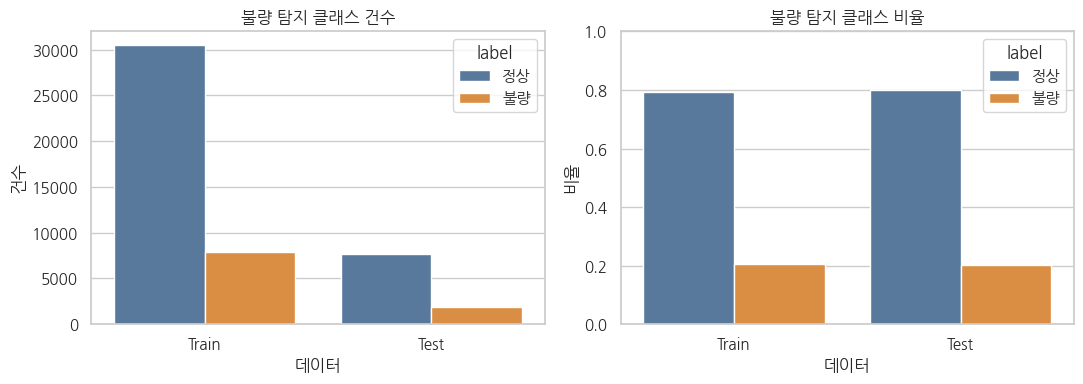

,split,label,count,ratio
0,Train,정상,30468,0.793438
1,Train,불량,7932,0.206563
2,Test,정상,7672,0.799167
3,Test,불량,1928,0.200833


defect_yn,정상 비율,불량 비율
process_code,,
ASSEMBLY,0.793438,0.206563
BODY,0.784479,0.215521
PAINT,0.779792,0.220208
PRESS,0.816042,0.183958


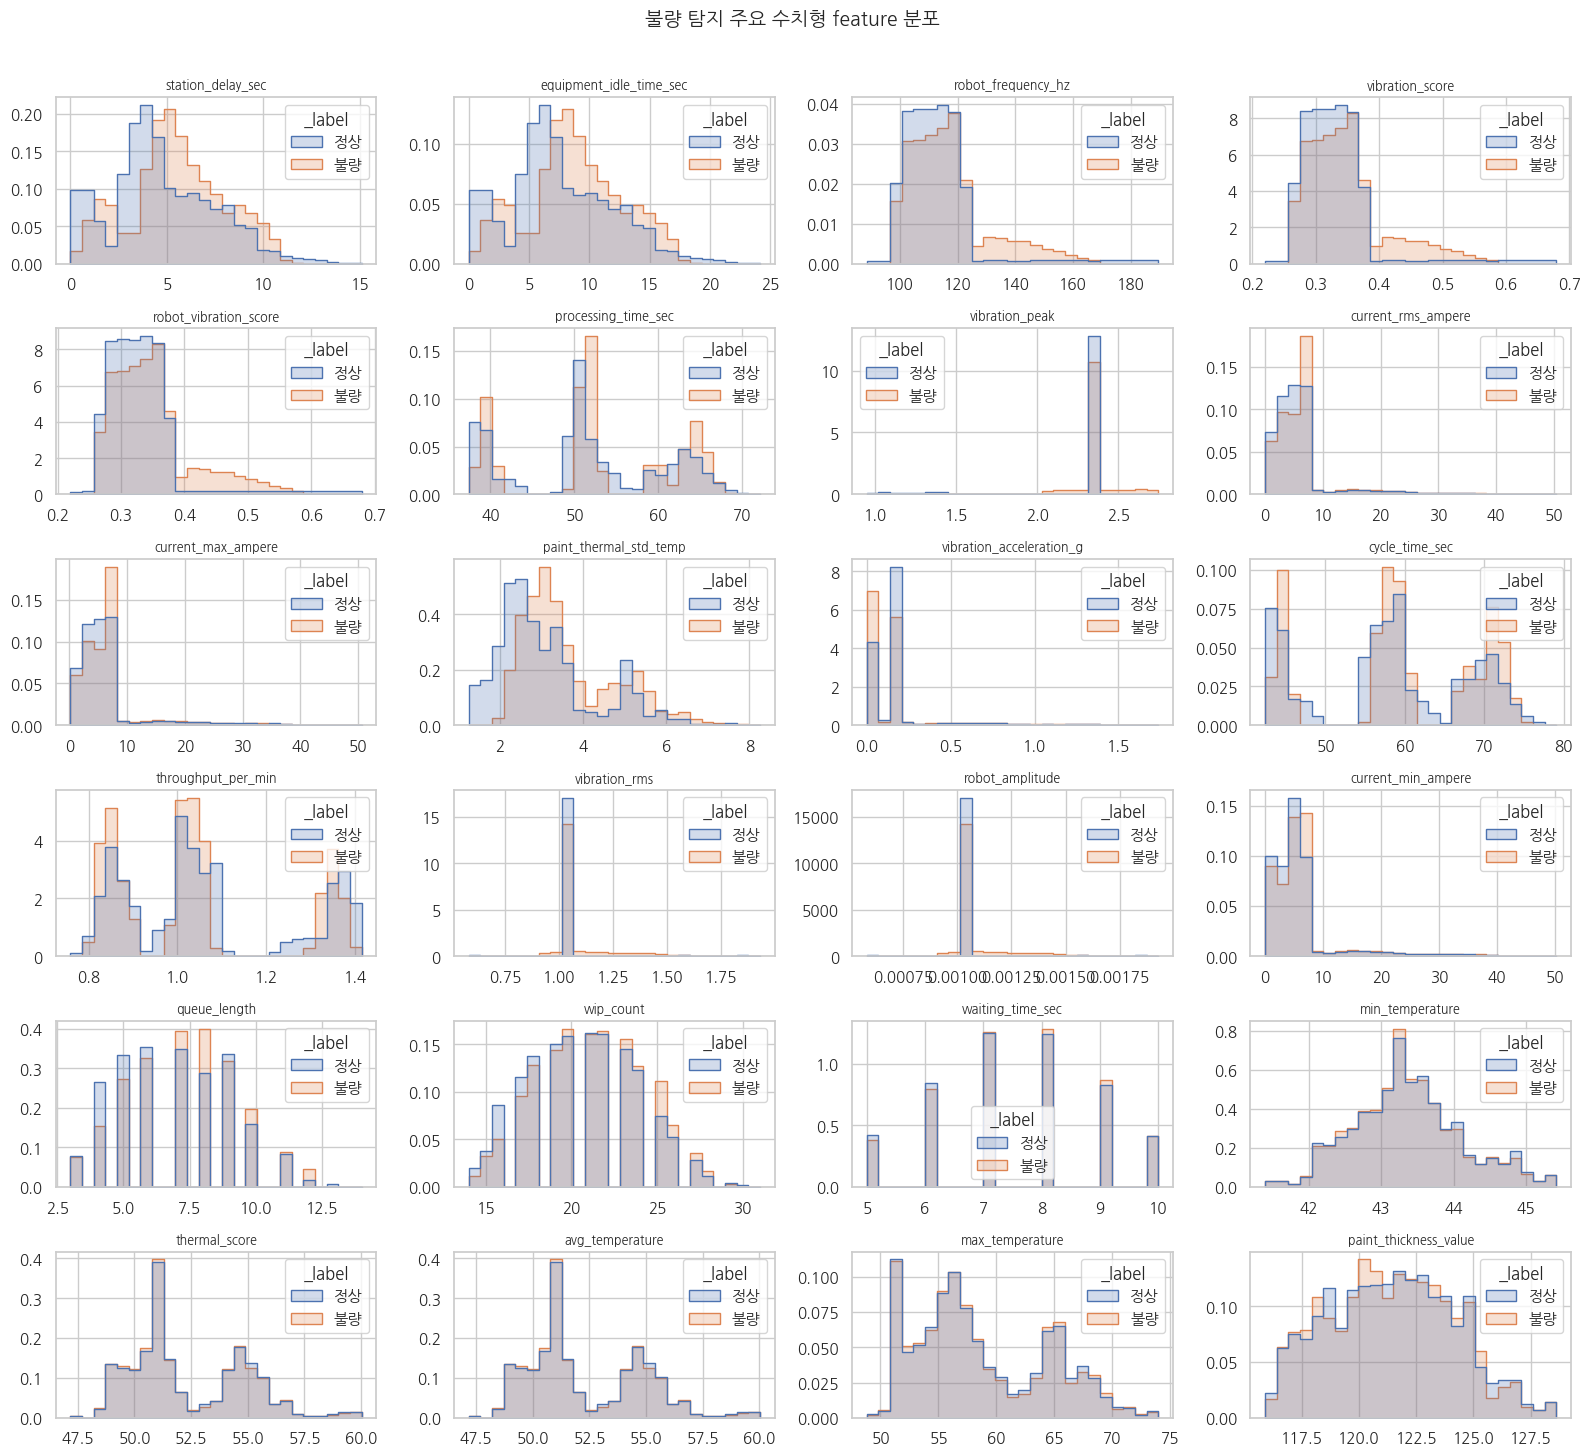

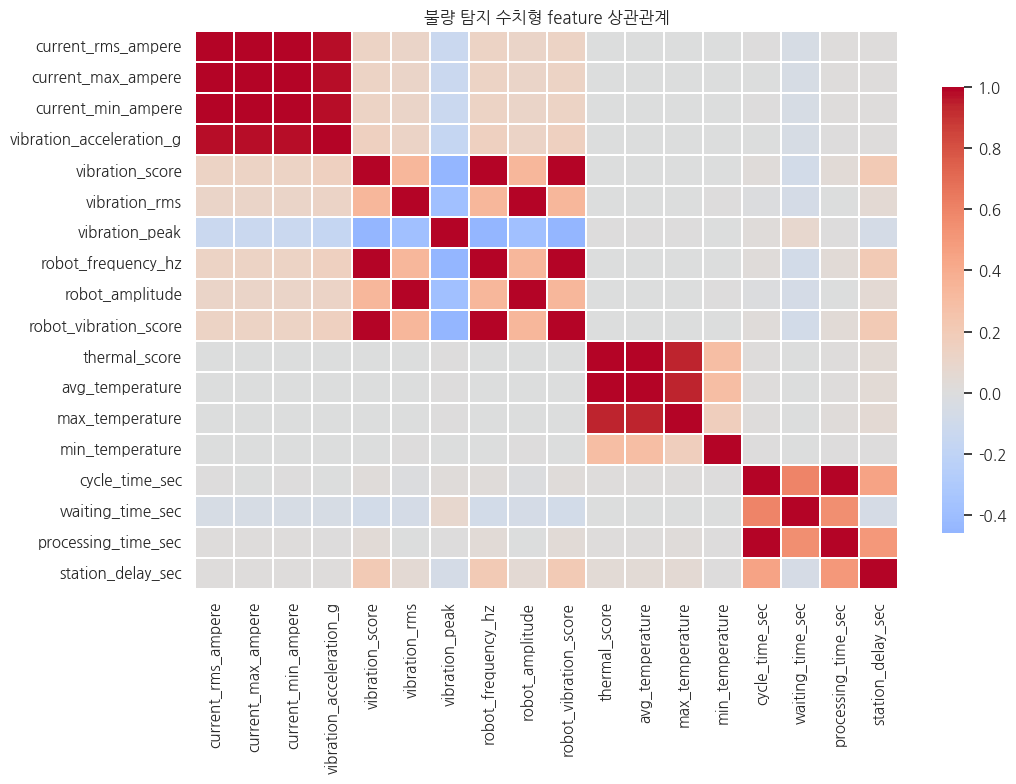

CV tuning rows: 12000 positive_ratio: 0.2066

[LightGBM] lightweight CV tuning: 3 trials x 3 folds
  trial 1: CV PR-AUC=0.9276, Recall=0.9371, F1=0.8022, elapsed=2.7s
  trial 2: CV PR-AUC=0.9345, Recall=0.9484, F1=0.8028, elapsed=3.1s
  trial 3: CV PR-AUC=0.9319, Recall=0.9383, F1=0.8065, elapsed=3.1s

[XGBoost] lightweight CV tuning: 3 trials x 3 folds
  trial 1: CV PR-AUC=0.8659, Recall=0.9480, F1=0.7192, elapsed=6.2s
  trial 2: CV PR-AUC=0.8457, Recall=0.9226, F1=0.7017, elapsed=2.1s
  trial 3: CV PR-AUC=0.8834, Recall=0.9544, F1=0.7215, elapsed=2.4s

[CatBoost] lightweight CV tuning: 3 trials x 3 folds
  trial 1: CV PR-AUC=0.8831, Recall=0.9584, F1=0.7240, elapsed=3.8s
  trial 2: CV PR-AUC=0.8565, Recall=0.9242, F1=0.7293, elapsed=5.2s
  trial 3: CV PR-AUC=0.9065, Recall=0.9318, F1=0.7725, elapsed=5.3s

[LogisticRegression] lightweight CV tuning: 3 trials x 3 folds
  trial 1: CV PR-AUC=0.5971, Recall=0.8596, F1=0.4502, elapsed=1.7s
  trial 2: CV PR-AUC=0.6095, Recall=0.8540, F1=0.4

,model_name,trial_no,cv_pr_auc,cv_recall,cv_precision,cv_f1,cv_accuracy,cv_threshold,elapsed_sec,params
0,LightGBM,2,0.934463,0.948366,0.697822,0.802814,0.903000,0.336858,3.108951,"{'model__subsample': 0.85, 'model__reg_lambda'..."
1,LightGBM,3,0.931911,0.938282,0.707198,0.806456,0.906917,0.388233,3.069297,"{'model__subsample': 0.95, 'model__reg_lambda'..."
2,LightGBM,1,0.927581,0.937072,0.701304,0.802172,0.904500,0.448503,2.653610,"{'model__subsample': 0.95, 'model__reg_lambda'..."
3,CatBoost,3,0.906456,0.931821,0.660354,0.772539,0.886417,0.518421,5.318331,"{'model__learning_rate': 0.045, 'model__l2_lea..."
4,XGBoost,3,0.883359,0.954416,0.580354,0.721533,0.847583,0.443721,2.388007,"{'model__subsample': 0.95, 'model__reg_lambda'..."
5,CatBoost,1,0.883073,0.958445,0.581853,0.724020,0.849000,0.450893,3.753630,"{'model__learning_rate': 0.035, 'model__l2_lea..."
6,XGBoost,1,0.865852,0.947958,0.579387,0.719196,0.847083,0.462588,6.186436,"{'model__subsample': 0.95, 'model__reg_lambda'..."
7,CatBoost,2,0.856514,0.924153,0.602729,0.729256,0.858167,0.493912,5.158900,"{'model__learning_rate': 0.035, 'model__l2_lea..."
8,XGBoost,2,0.845673,0.922552,0.567136,0.701664,0.837250,0.478727,2.087466,"{'model__subsample': 0.85, 'model__reg_lambda'..."
9,LogisticRegression,3,0.615725,0.858009,0.315055,0.459327,0.578833,0.377523,2.252431,{'model__C': 0.7}


모델별 선택 파라미터


,model_name,best_params
0,LightGBM,"{'model__subsample': 0.85, 'model__reg_lambda'..."
1,XGBoost,"{'model__subsample': 0.95, 'model__reg_lambda'..."
2,CatBoost,"{'model__learning_rate': 0.045, 'model__l2_lea..."
3,LogisticRegression,{'model__C': 0.7}



[LightGBM] final fit start
[LightGBM] Train F1=0.8789, Test F1=0.8426, Test PR-AUC=0.9560, Test Recall=0.9341

[XGBoost] final fit start
[XGBoost] Train F1=0.7436, Test F1=0.7425, Test PR-AUC=0.9029, Test Recall=0.9528

[CatBoost] final fit start
[CatBoost] Train F1=0.7799, Test F1=0.7698, Test PR-AUC=0.9181, Test Recall=0.9305

[LogisticRegression] final fit start
[LogisticRegression] Train F1=0.4686, Test F1=0.4597, Test PR-AUC=0.6526, Test Recall=0.8677
selected_event_model_name: LightGBM
불량 탐지 모델 학습 결과


,모델,Train F1,Test F1,Train 재현율,Test 재현율,Train 정밀도,Test 정밀도,Train 정확도,Test 정확도,Test PR-AUC,Test ROC-AUC,임계값(Train 기준),선택 파라미터
0,LightGBM,0.878897,0.842573,0.972138,0.934129,0.801976,0.767363,0.944661,0.929896,0.955974,0.986500,0.502521,"{'model__subsample': 0.85, 'model__reg_lambda'..."
1,CatBoost,0.779898,0.769792,0.943016,0.930498,0.664889,0.656422,0.890052,0.888229,0.918066,0.974119,0.525871,"{'model__learning_rate': 0.045, 'model__l2_lea..."
2,XGBoost,0.743551,0.742522,0.953858,0.952801,0.609228,0.608278,0.864089,0.867292,0.902932,0.968021,0.489376,"{'model__subsample': 0.95, 'model__reg_lambda'..."
3,LogisticRegression,0.468559,0.459742,0.861447,0.867739,0.321795,0.312710,0.596354,0.590417,0.652634,0.815697,0.377797,{'model__C': 0.7}


In [8]:
EVENT_TARGET = "defect_yn"
EVENT_LEAKAGE_COLS = [
    "defect_yn",
    "target_defect_yn",
    "defect_reason",
    "operation_status",
    "operation_status_raw",
    "quality_status",
    "paint_vision_label",
    "paint_defect_score",
    "paint_surface_quality_score",
    "assembly_missing_part_count",
    "assembly_fastening_error_count",
    "assembly_sequence_error_count",
    "assembly_sequence_mismatch_yn",
    "press_count_increase_yn",
    "press_timestamp_delay_sec",
    "body_robot_motion_status",
    "assembly_expected_sequence",
    "assembly_actual_sequence",
    "ford_row_id",
    "forming_row_id",
    "robot_arm_vibration_row_id",
    "machine_vision_row_id",
    "bosch_id",
]
EVENT_EXCLUDE_COLS = [
    "raw_event_id",
    "event_id",
    "event_time",
    "car_master_id",
    "defect_reason",
    EVENT_TARGET,
] + EVENT_LEAKAGE_COLS

event_feature_cols = select_model_features(defect_train, EVENT_TARGET, EVENT_EXCLUDE_COLS, EVENT_LEAKAGE_COLS, context="불량 탐지")
event_feature_cols = drop_suspicious_features(defect_train, EVENT_TARGET, event_feature_cols, context="불량 탐지")
ensure_feature_columns_exist(defect_test, event_feature_cols, context="불량 탐지")

X_event_train = defect_train[event_feature_cols]
y_event_train = defect_train[EVENT_TARGET].astype(int)
X_event_test = defect_test[event_feature_cols]
y_event_test = defect_test[EVENT_TARGET].astype(int)
event_scale_pos_weight = scale_pos_weight_for(y_event_train)

ENABLE_HYPERPARAMETER_TUNING = True
CV_FOLDS = 3
TUNING_TRIALS_PER_MODEL = 3
MAX_TUNING_ROWS = 12_000

print("불량 탐지 feature 수:", len(event_feature_cols))
print("불량 탐지 feature:", event_feature_cols)
print("불량 탐지 scale_pos_weight:", round(event_scale_pos_weight, 3))
print(f"튜닝 설정: enabled={ENABLE_HYPERPARAMETER_TUNING}, folds={CV_FOLDS}, trials={TUNING_TRIALS_PER_MODEL}, max_rows={MAX_TUNING_ROWS}")

plot_class_distribution(defect_train, defect_test, EVENT_TARGET, "불량 탐지")
display(pd.crosstab(defect_train["process_code"], defect_train[EVENT_TARGET], normalize="index").rename(columns={0: "정상 비율", 1: "불량 비율"}))
plot_feature_distribution_grid(defect_train, event_feature_cols, EVENT_TARGET, "불량 탐지 주요 수치형 feature 분포", max_features=24)
plot_numeric_correlation_heatmap(defect_train, event_feature_cols, "불량 탐지 수치형 feature 상관관계", max_features=18)


def make_event_model_configs(scale_pos_weight: float):
    return {
        "LightGBM": {
            "estimator": lgb.LGBMClassifier(
                objective="binary",
                n_estimators=220,
                learning_rate=0.045,
                num_leaves=15,
                min_child_samples=80,
                subsample=0.85,
                colsample_bytree=0.75,
                reg_lambda=8.0,
                scale_pos_weight=scale_pos_weight,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=-1,
            ),
            "scale_numeric": False,
            "param_distributions": {
                "model__n_estimators": [160, 220, 280],
                "model__learning_rate": [0.035, 0.045, 0.06],
                "model__num_leaves": [11, 15, 23],
                "model__min_child_samples": [60, 80, 120],
                "model__subsample": [0.75, 0.85, 0.95],
                "model__colsample_bytree": [0.70, 0.80, 0.90],
                "model__reg_lambda": [4.0, 8.0, 12.0],
            },
        },
        "XGBoost": {
            "estimator": xgb.XGBClassifier(
                objective="binary:logistic",
                eval_metric="aucpr",
                tree_method="hist",
                n_estimators=220,
                learning_rate=0.045,
                max_depth=3,
                min_child_weight=8,
                subsample=0.85,
                colsample_bytree=0.75,
                reg_lambda=8.0,
                scale_pos_weight=scale_pos_weight,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
            "scale_numeric": False,
            "param_distributions": {
                "model__n_estimators": [160, 220, 280],
                "model__learning_rate": [0.035, 0.045, 0.06],
                "model__max_depth": [2, 3, 4],
                "model__min_child_weight": [5, 8, 12],
                "model__subsample": [0.75, 0.85, 0.95],
                "model__colsample_bytree": [0.70, 0.80, 0.90],
                "model__reg_lambda": [4.0, 8.0, 12.0],
            },
        },
        "CatBoost": {
            "estimator": CatBoostClassifier(
                loss_function="Logloss",
                eval_metric="PRAUC",
                iterations=220,
                learning_rate=0.045,
                depth=4,
                l2_leaf_reg=10.0,
                scale_pos_weight=scale_pos_weight,
                random_seed=RANDOM_STATE,
                thread_count=2,
                verbose=False,
                allow_writing_files=False,
            ),
            "scale_numeric": False,
            "param_distributions": {
                "model__iterations": [160, 220, 280],
                "model__learning_rate": [0.035, 0.045, 0.06],
                "model__depth": [3, 4, 5],
                "model__l2_leaf_reg": [6.0, 10.0, 14.0],
            },
        },
        "LogisticRegression": {
            "estimator": LogisticRegression(class_weight="balanced", max_iter=1000, C=0.3, random_state=RANDOM_STATE),
            "scale_numeric": True,
            "param_distributions": {
                "model__C": [0.1, 0.3, 0.7],
            },
        },
    }


def make_model_pipeline(config, train_df, feature_cols):
    return Pipeline([
        ("preprocess", make_preprocessor(train_df, feature_cols, scale_numeric=config.get("scale_numeric", False))),
        ("model", clone(config["estimator"])),
    ])


def sample_param_candidates(param_distributions: dict, n_iter: int, random_state: int):
    if not param_distributions:
        return [{}]
    return list(ParameterSampler(param_distributions, n_iter=n_iter, random_state=random_state))


def make_tuning_sample(X: pd.DataFrame, y: pd.Series, max_rows: int):
    if len(X) <= max_rows:
        return X, y
    sampled_parts = []
    for label, label_index in y.groupby(y).groups.items():
        label_index = pd.Index(label_index)
        n_rows = max(1, int(round(len(label_index) / len(y) * max_rows)))
        sampled_parts.append(label_index.to_series().sample(n=min(n_rows, len(label_index)), random_state=RANDOM_STATE))
    sampled_index = pd.Index(pd.concat(sampled_parts).tolist())
    if len(sampled_index) > max_rows:
        sampled_index = sampled_index.to_series().sample(max_rows, random_state=RANDOM_STATE).index
    sampled_index = sampled_index.sort_values()
    return X.loc[sampled_index], y.loc[sampled_index]


def tune_event_model_cv(model_name: str, config: dict, X: pd.DataFrame, y: pd.Series, feature_cols: list[str]):
    candidates = sample_param_candidates(config.get("param_distributions", {}), TUNING_TRIALS_PER_MODEL, RANDOM_STATE)
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    best_row = None
    best_score = (-np.inf, -np.inf, -np.inf)
    print(f"\n[{model_name}] lightweight CV tuning: {len(candidates)} trials x {CV_FOLDS} folds")
    for trial_no, params in enumerate(candidates, start=1):
        fold_metrics = []
        started_at = time.perf_counter()
        for train_idx, valid_idx in cv.split(X, y):
            X_fold_train = X.iloc[train_idx]
            y_fold_train = y.iloc[train_idx]
            X_fold_valid = X.iloc[valid_idx]
            y_fold_valid = y.iloc[valid_idx]
            estimator = make_model_pipeline(config, X_fold_train, feature_cols)
            estimator.set_params(**params)
            estimator.fit(X_fold_train, y_fold_train)
            valid_proba = predict_positive_proba(estimator, X_fold_valid)
            threshold = find_recall_priority_threshold(y_fold_valid, valid_proba, min_recall=0.65, min_precision=0.20)
            fold_metrics.append(compute_metrics(y_fold_valid, valid_proba, threshold))
        elapsed_sec = time.perf_counter() - started_at
        row = {
            "model_name": model_name,
            "trial_no": trial_no,
            "params": params,
            "cv_pr_auc": float(np.mean([m["pr_auc"] for m in fold_metrics])),
            "cv_recall": float(np.mean([m["recall"] for m in fold_metrics])),
            "cv_precision": float(np.mean([m["precision"] for m in fold_metrics])),
            "cv_f1": float(np.mean([m["f1"] for m in fold_metrics])),
            "cv_accuracy": float(np.mean([m["accuracy"] for m in fold_metrics])),
            "cv_threshold": float(np.mean([m["threshold"] for m in fold_metrics])),
            "elapsed_sec": elapsed_sec,
        }
        rows.append(row)
        score = (row["cv_pr_auc"], row["cv_recall"], row["cv_f1"])
        if score > best_score:
            best_score = score
            best_row = row
        print(f"  trial {trial_no}: CV PR-AUC={row['cv_pr_auc']:.4f}, Recall={row['cv_recall']:.4f}, F1={row['cv_f1']:.4f}, elapsed={elapsed_sec:.1f}s")
    return best_row, rows


event_model_configs = make_event_model_configs(event_scale_pos_weight)
event_best_params = {model_name: {} for model_name in event_model_configs}
event_cv_rows = []
X_event_tune, y_event_tune = make_tuning_sample(X_event_train, y_event_train, MAX_TUNING_ROWS)
print("CV tuning rows:", len(X_event_tune), "positive_ratio:", round(float(y_event_tune.mean()), 4))

if ENABLE_HYPERPARAMETER_TUNING:
    for model_name, config in event_model_configs.items():
        best_row, rows = tune_event_model_cv(model_name, config, X_event_tune, y_event_tune, event_feature_cols)
        event_cv_rows.extend(rows)
        event_best_params[model_name] = best_row["params"] if best_row else {}

event_cv_results = pd.DataFrame(event_cv_rows)
if not event_cv_results.empty:
    display(
        event_cv_results.sort_values(["cv_pr_auc", "cv_recall", "cv_f1"], ascending=False)
        [["model_name", "trial_no", "cv_pr_auc", "cv_recall", "cv_precision", "cv_f1", "cv_accuracy", "cv_threshold", "elapsed_sec", "params"]]
        .reset_index(drop=True)
    )
print("모델별 선택 파라미터")
display(pd.DataFrame([{"model_name": model_name, "best_params": params} for model_name, params in event_best_params.items()]))

event_candidate_models = {}
event_eval_rows = []
event_train_proba_by_model = {}
event_test_proba_by_model = {}

for model_name, config in event_model_configs.items():
    print(f"\n[{model_name}] final fit start")
    estimator = make_model_pipeline(config, defect_train, event_feature_cols)
    estimator.set_params(**event_best_params.get(model_name, {}))
    estimator.fit(X_event_train, y_event_train)
    train_proba = predict_positive_proba(estimator, X_event_train)
    test_proba = predict_positive_proba(estimator, X_event_test)
    threshold = find_recall_priority_threshold(y_event_train, train_proba, min_recall=0.65, min_precision=0.20)
    train_metrics = compute_metrics(y_event_train, train_proba, threshold)
    test_metrics = compute_metrics(y_event_test, test_proba, threshold)
    event_candidate_models[model_name] = estimator
    event_train_proba_by_model[model_name] = train_proba
    event_test_proba_by_model[model_name] = test_proba
    event_eval_rows.append({
        "model_name": model_name,
        "threshold": threshold,
        "best_params": event_best_params.get(model_name, {}),
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"test_{k}": v for k, v in test_metrics.items()},
    })
    print(f"[{model_name}] Train F1={train_metrics['f1']:.4f}, Test F1={test_metrics['f1']:.4f}, Test PR-AUC={test_metrics['pr_auc']:.4f}, Test Recall={test_metrics['recall']:.4f}")

event_model_comparison = pd.DataFrame(event_eval_rows).sort_values(["test_pr_auc", "test_recall", "test_f1"], ascending=False).reset_index(drop=True)
selected_event_model_name = str(event_model_comparison.iloc[0]["model_name"])
selected_event_threshold = float(event_model_comparison.iloc[0]["threshold"])
selected_event_model = event_candidate_models[selected_event_model_name]
print("selected_event_model_name:", selected_event_model_name)

event_model_result_table = event_model_comparison[[
    "model_name",
    "train_f1", "test_f1",
    "train_recall", "test_recall",
    "train_precision", "test_precision",
    "train_accuracy", "test_accuracy",
    "test_pr_auc", "test_roc_auc",
    "threshold",
    "best_params",
]].rename(columns={
    "model_name": "모델",
    "train_f1": "Train F1",
    "test_f1": "Test F1",
    "train_recall": "Train 재현율",
    "test_recall": "Test 재현율",
    "train_precision": "Train 정밀도",
    "test_precision": "Test 정밀도",
    "train_accuracy": "Train 정확도",
    "test_accuracy": "Test 정확도",
    "test_pr_auc": "Test PR-AUC",
    "test_roc_auc": "Test ROC-AUC",
    "threshold": "임계값(Train 기준)",
    "best_params": "선택 파라미터",
})
print("불량 탐지 모델 학습 결과")
display(event_model_result_table)

**셀 설명**

후보 모델별 평가 지표와 혼동행렬을 출력하고, 선택된 모델의 classification report, PR 곡선, ROC 곡선을 시각화합니다.

불량 탐지 모델별 평가 지표


,모델,Train F1,Test F1,Train 재현율,Test 재현율,Train 정밀도,Test 정밀도,Train 정확도,Test 정확도,Test PR-AUC,Test ROC-AUC,임계값(Train 기준),선택 파라미터
0,LightGBM,0.878897,0.842573,0.972138,0.934129,0.801976,0.767363,0.944661,0.929896,0.955974,0.986500,0.502521,"{'model__subsample': 0.85, 'model__reg_lambda'..."
1,CatBoost,0.779898,0.769792,0.943016,0.930498,0.664889,0.656422,0.890052,0.888229,0.918066,0.974119,0.525871,"{'model__learning_rate': 0.045, 'model__l2_lea..."
2,XGBoost,0.743551,0.742522,0.953858,0.952801,0.609228,0.608278,0.864089,0.867292,0.902932,0.968021,0.489376,"{'model__subsample': 0.95, 'model__reg_lambda'..."
3,LogisticRegression,0.468559,0.459742,0.861447,0.867739,0.321795,0.312710,0.596354,0.590417,0.652634,0.815697,0.377797,{'model__C': 0.7}



[LightGBM] Train/Test 혼동행렬
Train FP=1904 FN=221 | Test FP=546 FN=127


,split,threshold,pr_auc,roc_auc,accuracy,precision,recall,f1,false_positive_rate,tn,fp,fn,tp
0,Train,0.502521,0.974105,0.992645,0.944661,0.801976,0.972138,0.878897,0.062492,28564,1904,221,7711
1,Test,0.502521,0.955974,0.986500,0.929896,0.767363,0.934129,0.842573,0.071168,7126,546,127,1801



[CatBoost] Train/Test 혼동행렬
Train FP=3770 FN=452 | Test FP=939 FN=134


,split,threshold,pr_auc,roc_auc,accuracy,precision,recall,f1,false_positive_rate,tn,fp,fn,tp
0,Train,0.525871,0.923610,0.975237,0.890052,0.664889,0.943016,0.779898,0.123736,26698,3770,452,7480
1,Test,0.525871,0.918066,0.974119,0.888229,0.656422,0.930498,0.769792,0.122393,6733,939,134,1794



[XGBoost] Train/Test 혼동행렬
Train FP=4853 FN=366 | Test FP=1183 FN=91


,split,threshold,pr_auc,roc_auc,accuracy,precision,recall,f1,false_positive_rate,tn,fp,fn,tp
0,Train,0.489376,0.904375,0.967881,0.864089,0.609228,0.953858,0.743551,0.159282,25615,4853,366,7566
1,Test,0.489376,0.902932,0.968021,0.867292,0.608278,0.952801,0.742522,0.154197,6489,1183,91,1837



[LogisticRegression] Train/Test 혼동행렬
Train FP=14401 FN=1099 | Test FP=3677 FN=255


,split,threshold,pr_auc,roc_auc,accuracy,precision,recall,f1,false_positive_rate,tn,fp,fn,tp
0,Train,0.377797,0.655090,0.815531,0.596354,0.321795,0.861447,0.468559,0.472660,16067,14401,1099,6833
1,Test,0.377797,0.652634,0.815697,0.590417,0.312710,0.867739,0.459742,0.479275,3995,3677,255,1673


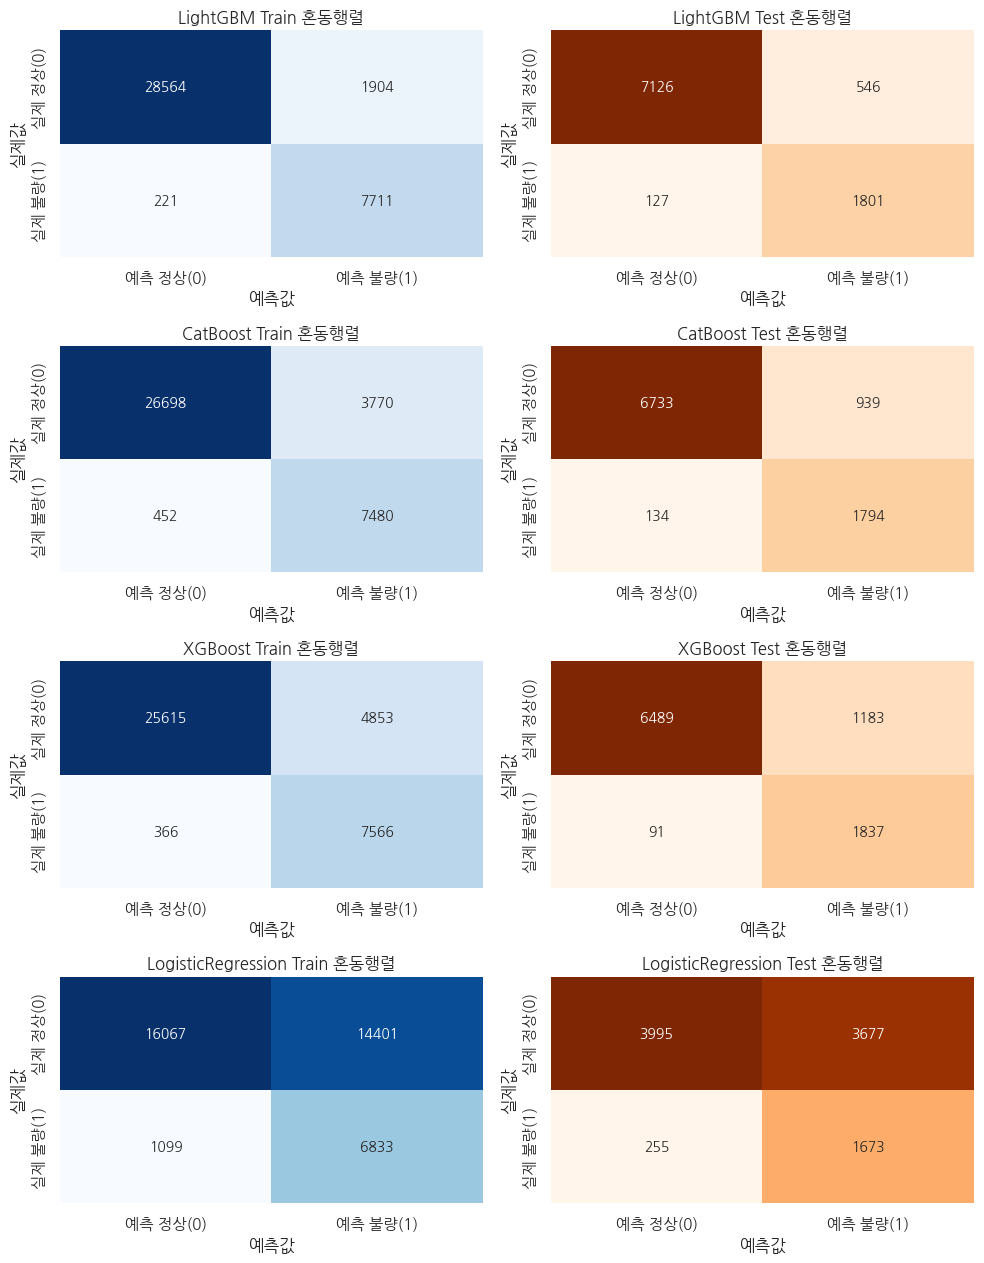

선택 모델: LightGBM
              precision    recall  f1-score   support

          정상     0.9825    0.9288    0.9549      7672
          불량     0.7674    0.9341    0.8426      1928

    accuracy                         0.9299      9600
   macro avg     0.8749    0.9315    0.8987      9600
weighted avg     0.9393    0.9299    0.9323      9600



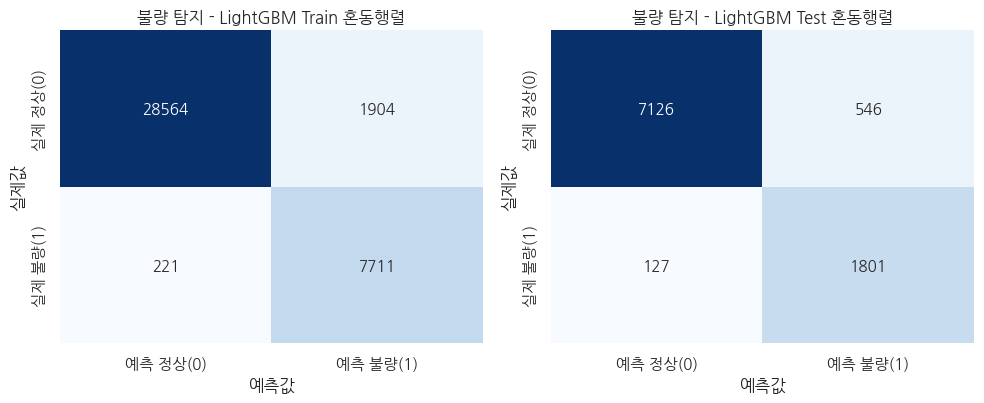

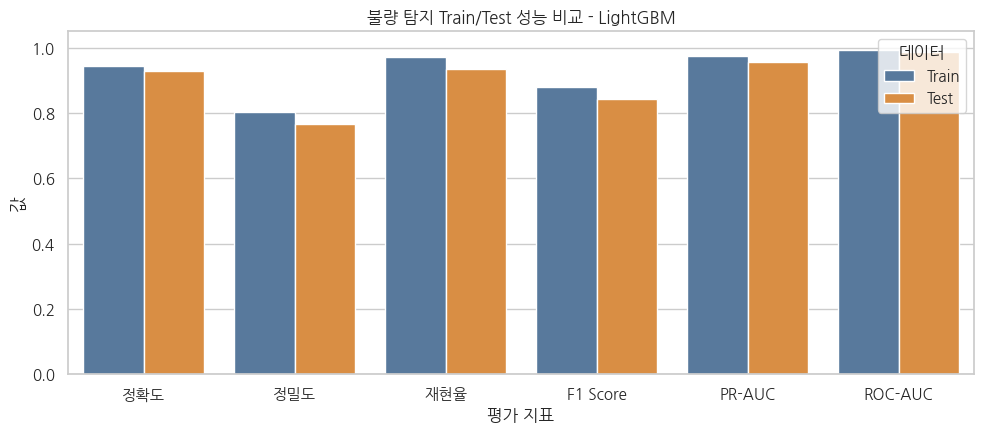

split,metric,Test,Train
0,F1 Score,0.842573,0.878897
1,PR-AUC,0.955974,0.974105
2,ROC-AUC,0.986500,0.992645
3,재현율,0.934129,0.972138
4,정밀도,0.767363,0.801976
5,정확도,0.929896,0.944661


재현율(Recall): 0.9341
정밀도(Precision): 0.7674
F1 Score: 0.8426
PR-AUC: 0.9560
임계값(Threshold): 0.5025


,지표,값
0,정확도(Accuracy),0.929896
1,정밀도(Precision),0.767363
2,재현율(Recall),0.934129
3,F1 Score,0.842573
4,ROC-AUC,0.986500
5,PR-AUC,0.955974
6,오탐률(False Positive Rate),0.071168
7,임계값(Threshold),0.502521


,예측 정상(0),예측 불량(1)
실제 정상(0),7126,546
실제 불량(1),127,1801


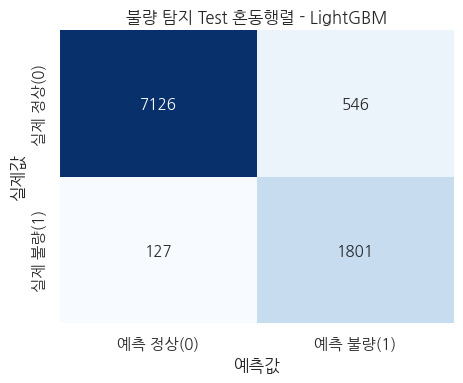

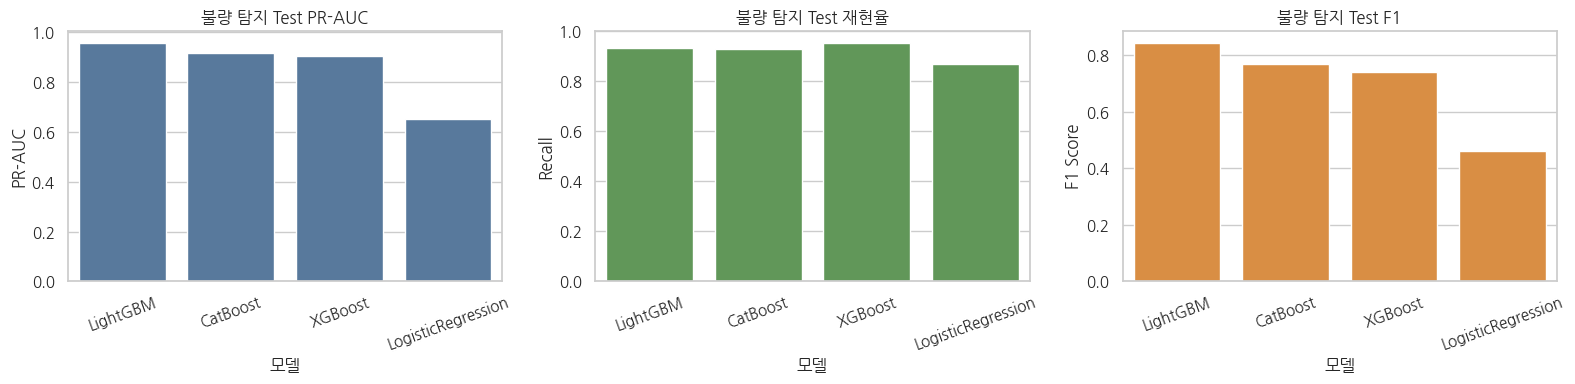

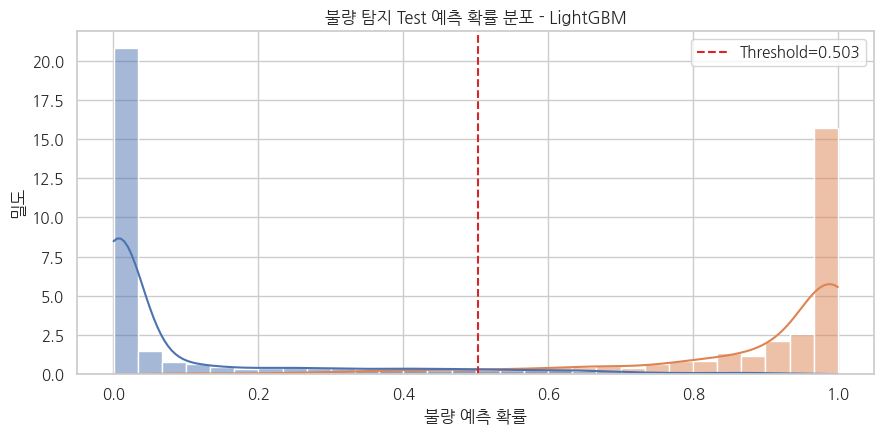

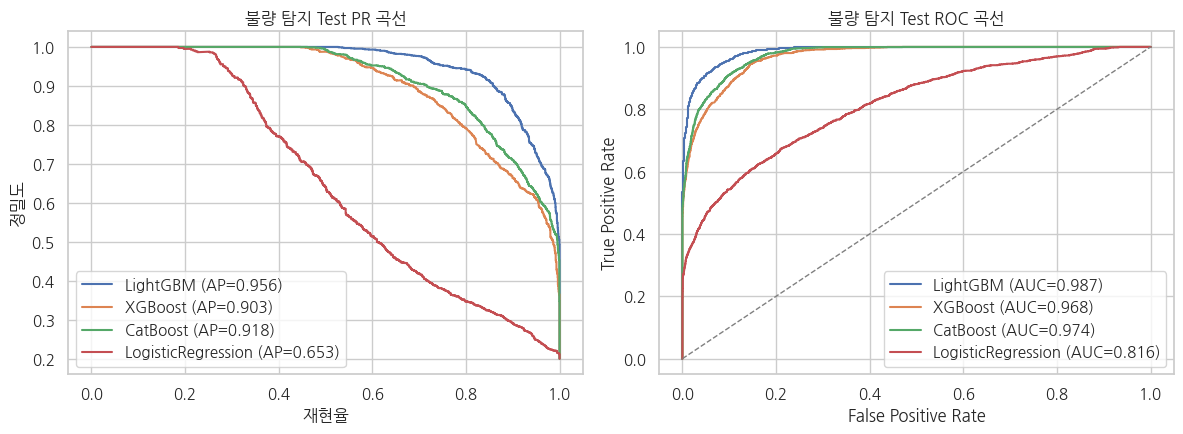

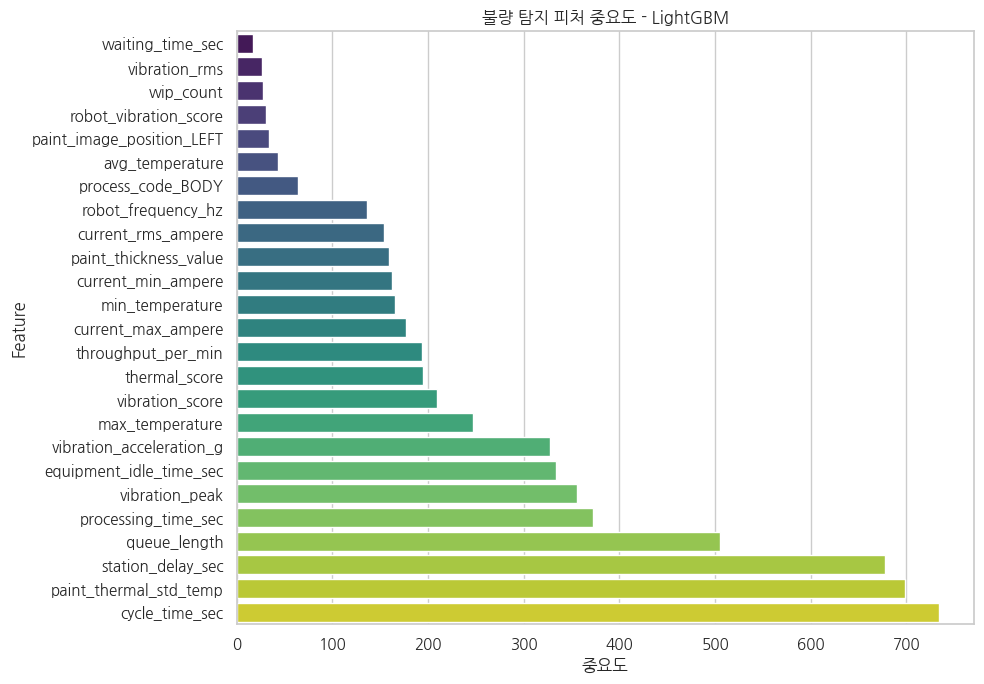

,feature,importance,importance_ratio
0,cycle_time_sec,734.0,0.119156
1,paint_thermal_std_temp,699.0,0.113474
2,station_delay_sec,678.0,0.110065
3,queue_length,505.0,0.081981
4,processing_time_sec,372.0,0.060390
5,vibration_peak,356.0,0.057792
6,equipment_idle_time_sec,334.0,0.054221
7,vibration_acceleration_g,327.0,0.053084
8,max_temperature,247.0,0.040097
9,vibration_score,209.0,0.033929


In [9]:
print("불량 탐지 모델별 평가 지표")
display(event_model_result_table)

event_confusion_tables_by_model = {}
event_train_confusion_tables_by_model = {}
event_confusion_metric_rows = []

for model_name in event_model_comparison["model_name"]:
    threshold = float(event_model_comparison.loc[event_model_comparison["model_name"] == model_name, "threshold"].iloc[0])
    train_proba = event_train_proba_by_model[model_name]
    test_proba = event_test_proba_by_model[model_name]
    train_metrics = compute_metrics(y_event_train, train_proba, threshold)
    test_metrics = compute_metrics(y_event_test, test_proba, threshold)
    event_train_confusion_tables_by_model[model_name] = confusion_matrix_table(train_metrics)
    event_confusion_tables_by_model[model_name] = confusion_matrix_table(test_metrics)
    event_confusion_metric_rows.append({
        "model_name": model_name,
        "threshold": threshold,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"test_{k}": v for k, v in test_metrics.items()},
    })
    print(f"\n[{model_name}] Train/Test 혼동행렬")
    print(f"Train FP={train_metrics['fp']} FN={train_metrics['fn']} | Test FP={test_metrics['fp']} FN={test_metrics['fn']}")
    display(pd.DataFrame([
        {"split": "Train", **train_metrics},
        {"split": "Test", **test_metrics},
    ]))

event_confusion_metrics_by_model = pd.DataFrame(event_confusion_metric_rows)

fig, axes = plt.subplots(len(event_model_comparison), 2, figsize=(10, max(4, len(event_model_comparison) * 3.2)))
axes = np.array(axes).reshape(len(event_model_comparison), 2)
for row_idx, model_name in enumerate(event_model_comparison["model_name"]):
    sns.heatmap(event_train_confusion_tables_by_model[model_name], annot=True, fmt="d", cmap="Blues", ax=axes[row_idx, 0], cbar=False, annot_kws={"size": 10})
    axes[row_idx, 0].set_title(f"{model_name} Train 혼동행렬")
    axes[row_idx, 0].set_xlabel("예측값")
    axes[row_idx, 0].set_ylabel("실제값")
    sns.heatmap(event_confusion_tables_by_model[model_name], annot=True, fmt="d", cmap="Oranges", ax=axes[row_idx, 1], cbar=False, annot_kws={"size": 10})
    axes[row_idx, 1].set_title(f"{model_name} Test 혼동행렬")
    axes[row_idx, 1].set_xlabel("예측값")
    axes[row_idx, 1].set_ylabel("실제값")
plt.tight_layout()
plt.show()

event_train_proba = event_train_proba_by_model[selected_event_model_name]
event_test_proba = event_test_proba_by_model[selected_event_model_name]
event_test_pred = (event_test_proba >= selected_event_threshold).astype(int)
print(f"선택 모델: {selected_event_model_name}")
print(classification_report(y_event_test, event_test_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))

event_train_metrics, event_test_metrics = plot_train_test_confusion(
    y_event_train,
    event_train_proba,
    y_event_test,
    event_test_proba,
    selected_event_threshold,
    f"불량 탐지 - {selected_event_model_name}",
)
plot_train_test_metric_comparison(event_train_metrics, event_test_metrics, f"불량 탐지 Train/Test 성능 비교 - {selected_event_model_name}")

event_metric_summary_table, event_confusion_matrix_table = display_confusion_matrix_report(
    y_event_test, event_test_proba, selected_event_threshold, title=f"불량 탐지 Test 혼동행렬 - {selected_event_model_name}"
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.barplot(data=event_model_comparison, x="model_name", y="test_pr_auc", ax=axes[0], color="#4C78A8")
axes[0].set_title("불량 탐지 Test PR-AUC")
axes[0].set_xlabel("모델")
axes[0].set_ylabel("PR-AUC")
axes[0].tick_params(axis="x", rotation=20)
sns.barplot(data=event_model_comparison, x="model_name", y="test_recall", ax=axes[1], color="#59A14F")
axes[1].set_title("불량 탐지 Test 재현율")
axes[1].set_xlabel("모델")
axes[1].set_ylabel("Recall")
axes[1].tick_params(axis="x", rotation=20)
sns.barplot(data=event_model_comparison, x="model_name", y="test_f1", ax=axes[2], color="#F28E2B")
axes[2].set_title("불량 탐지 Test F1")
axes[2].set_xlabel("모델")
axes[2].set_ylabel("F1 Score")
axes[2].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

plot_probability_distribution(y_event_test, event_test_proba, selected_event_threshold, f"불량 탐지 Test 예측 확률 분포 - {selected_event_model_name}")
plot_pr_roc_curves(y_event_test, event_test_proba_by_model, "불량 탐지 Test")

event_model_importance = model_feature_importance(selected_event_model)
plot_model_feature_importance(event_model_importance, f"불량 탐지 피처 중요도 - {selected_event_model_name}", top_n=25)

## 5. SHAP 불량 원인 분석

**셀 설명**

선택된 불량 탐지 모델의 SHAP 중요도를 계산해 어떤 feature가 예측에 크게 기여했는지 확인합니다.

,feature,mean_abs_shap
0,vibration_acceleration_g,1.142834
1,cycle_time_sec,0.966047
2,vibration_peak,0.894833
3,process_code_BODY,0.701656
4,current_max_ampere,0.434145
5,current_rms_ampere,0.372167
6,station_delay_sec,0.360060
7,processing_time_sec,0.318584
8,paint_thermal_std_temp,0.279638
9,queue_length,0.257782


,row_index,defect_probability,risk_grade,top_features
97,7585,0.999328,HIGH,"[{'feature': 'vibration_peak', 'shap_value': 9..."
81,1793,0.999281,HIGH,"[{'feature': 'vibration_peak', 'shap_value': 9..."
123,1593,0.999256,HIGH,"[{'feature': 'vibration_peak', 'shap_value': 9..."
332,4265,0.999209,HIGH,"[{'feature': 'vibration_peak', 'shap_value': 9..."
128,2165,0.999164,HIGH,"[{'feature': 'vibration_peak', 'shap_value': 9..."
253,457,0.999110,HIGH,"[{'feature': 'vibration_peak', 'shap_value': 9..."
383,7169,0.999089,HIGH,"[{'feature': 'vibration_peak', 'shap_value': 9..."
316,2701,0.999051,HIGH,"[{'feature': 'vibration_peak', 'shap_value': 9..."
377,2373,0.998991,HIGH,"[{'feature': 'vibration_peak', 'shap_value': 9..."
483,3653,0.998952,HIGH,"[{'feature': 'vibration_peak', 'shap_value': 9..."


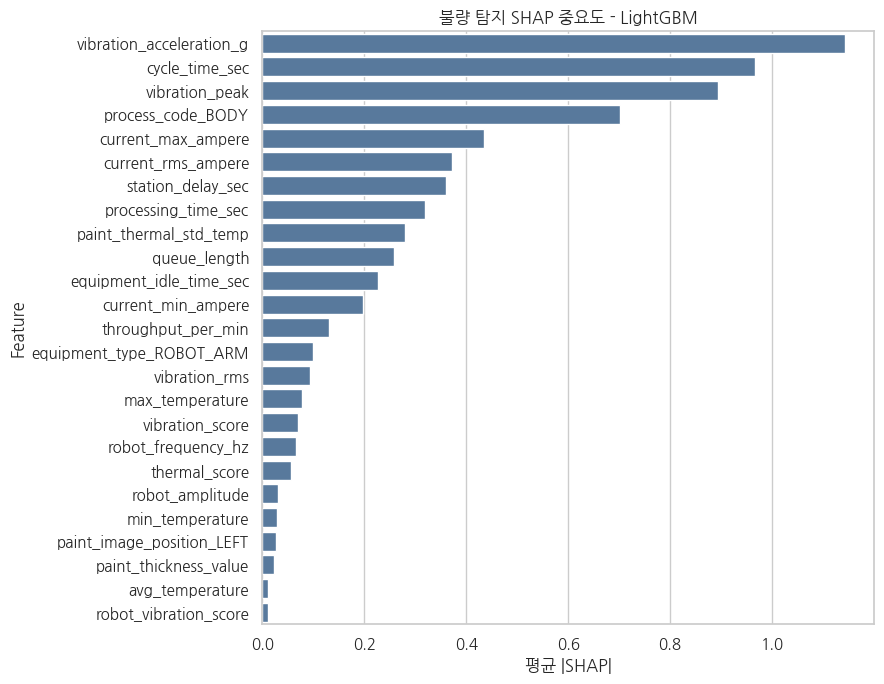

In [10]:
def transformed_feature_names(pipeline):
    return pipeline.named_steps["preprocess"].get_feature_names_out().tolist()


def compute_shap_importance(pipeline, X, sample_size=500):
    X_sample = X.sample(min(sample_size, len(X)), random_state=RANDOM_STATE)
    preprocessor = pipeline.named_steps["preprocess"]
    model = pipeline.named_steps["model"]
    X_transformed = preprocessor.transform(X_sample)
    feature_names = transformed_feature_names(pipeline)
    try:
        explainer = shap.TreeExplainer(model)
        raw_values = explainer.shap_values(X_transformed, check_additivity=False)
        if isinstance(raw_values, list):
            shap_matrix = np.asarray(raw_values[1])
        elif getattr(raw_values, "ndim", 0) == 3:
            shap_matrix = np.asarray(raw_values[:, :, 1])
        else:
            shap_matrix = np.asarray(raw_values)
    except Exception as exc:
        print("TreeExplainer 실패, model-agnostic Explainer로 대체:", exc)
        background = preprocessor.transform(X.sample(min(100, len(X)), random_state=RANDOM_STATE))
        explainer = shap.Explainer(lambda data: model.predict_proba(data)[:, 1], background)
        shap_matrix = np.asarray(explainer(X_transformed, max_evals=min(2 * X_transformed.shape[1] + 1, 1000)).values)
    importance = pd.DataFrame({"feature": feature_names, "mean_abs_shap": np.abs(shap_matrix).mean(axis=0)}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    sample_proba = predict_positive_proba(pipeline, X_sample)
    examples = []
    for row_pos, row_idx in enumerate(X_sample.index):
        abs_values = np.abs(shap_matrix[row_pos])
        top_idx = abs_values.argsort()[::-1][:5]
        examples.append({"row_index": int(row_idx), "defect_probability": float(sample_proba[row_pos]), "risk_grade": risk_grade(float(sample_proba[row_pos])), "top_features": [{"feature": feature_names[i], "shap_value": float(shap_matrix[row_pos, i]), "abs_shap": float(abs_values[i])} for i in top_idx]})
    return importance, pd.DataFrame(examples)


event_shap_importance, event_shap_examples = compute_shap_importance(selected_event_model, X_event_test)
display(event_shap_importance.head(30))
display(event_shap_examples.sort_values("defect_probability", ascending=False).head(20))
plt.figure(figsize=(9, 7))
sns.barplot(data=event_shap_importance.head(25), x="mean_abs_shap", y="feature", color="#4C78A8")
plt.title(f"불량 탐지 SHAP 중요도 - {selected_event_model_name}")
plt.xlabel("평균 |SHAP|")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 6. 공정 간 불량 전이 예측 모델링

**셀 설명**

PRESS->BODY, BODY->PAINT, PAINT->ASSEMBLY 흐름별로 다음 공정 불량 가능성을 예측합니다. 실제 운영에서 이미 관측된 source 공정의 정답 라벨은 과도한 지름길이 될 수 있어 기본 feature에서 제외합니다.

공정 전이 예측 정답 유출 방지 제외 컬럼: ['source_defect_yn']
공정 전이 예측 단일 feature 예측력 상위 10개


,feature,single_feature_auc
4,source_current_rms_ampere,0.521400
5,source_vibration_score,0.521281
1,source_station_delay_sec,0.517898
2,source_queue_length,0.504349
6,source_thermal_score,0.503262
0,source_cycle_time_sec,0.503251
3,source_wip_count,0.502044


공정 전이 예측 feature 수: 7
공정 전이 예측 feature: ['source_cycle_time_sec', 'source_station_delay_sec', 'source_queue_length', 'source_wip_count', 'source_current_rms_ampere', 'source_vibration_score', 'source_thermal_score']


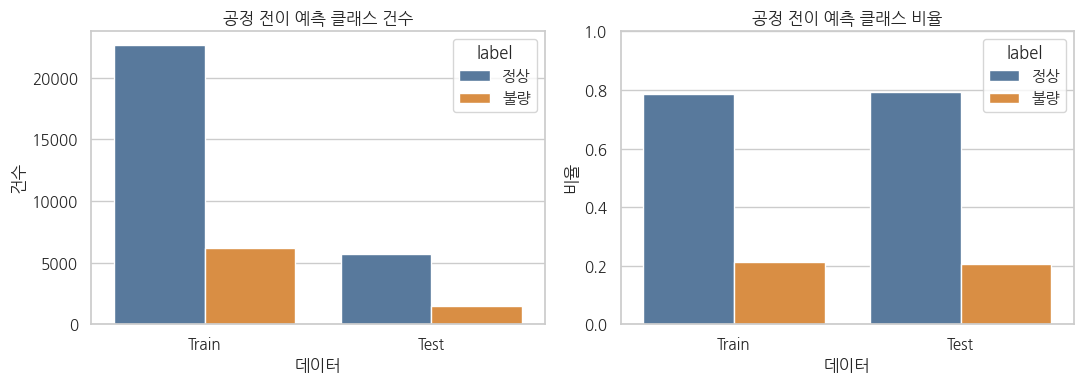

,split,label,count,ratio
0,Train,정상,22634,0.785903
1,Train,불량,6166,0.214097
2,Test,정상,5708,0.792778
3,Test,불량,1492,0.207222


,target_defect_yn,정상 비율,전이 양성 비율
source_process_code,target_process_code,,
BODY,PAINT,0.779792,0.220208
PAINT,ASSEMBLY,0.793438,0.206563
PRESS,BODY,0.784479,0.215521


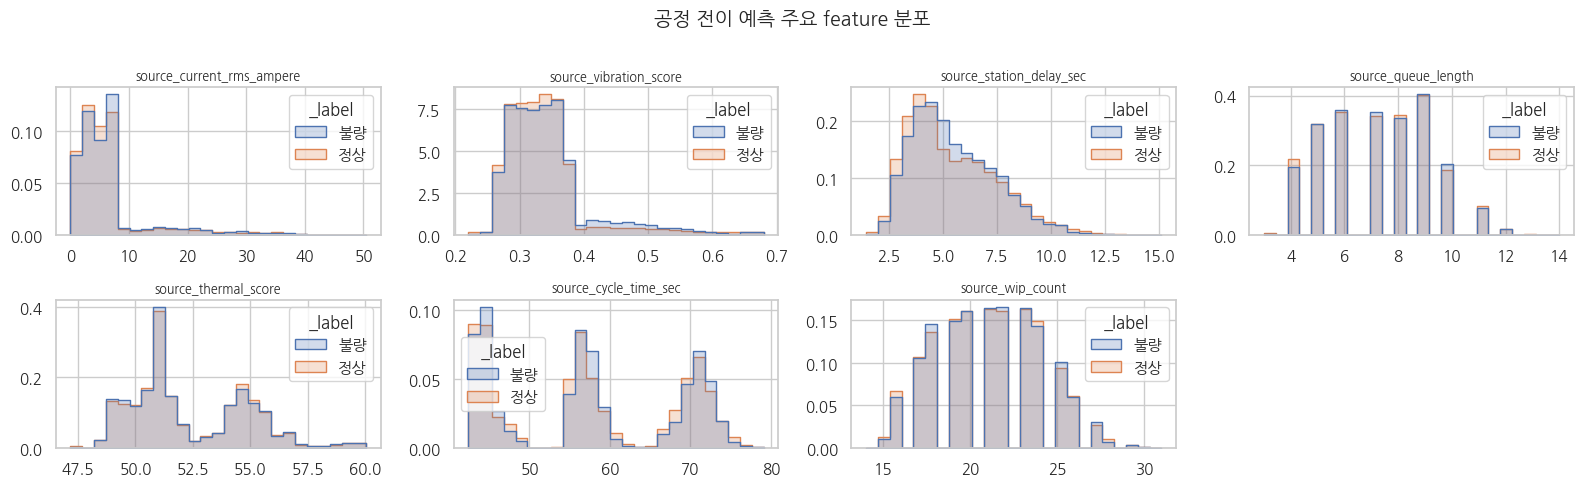

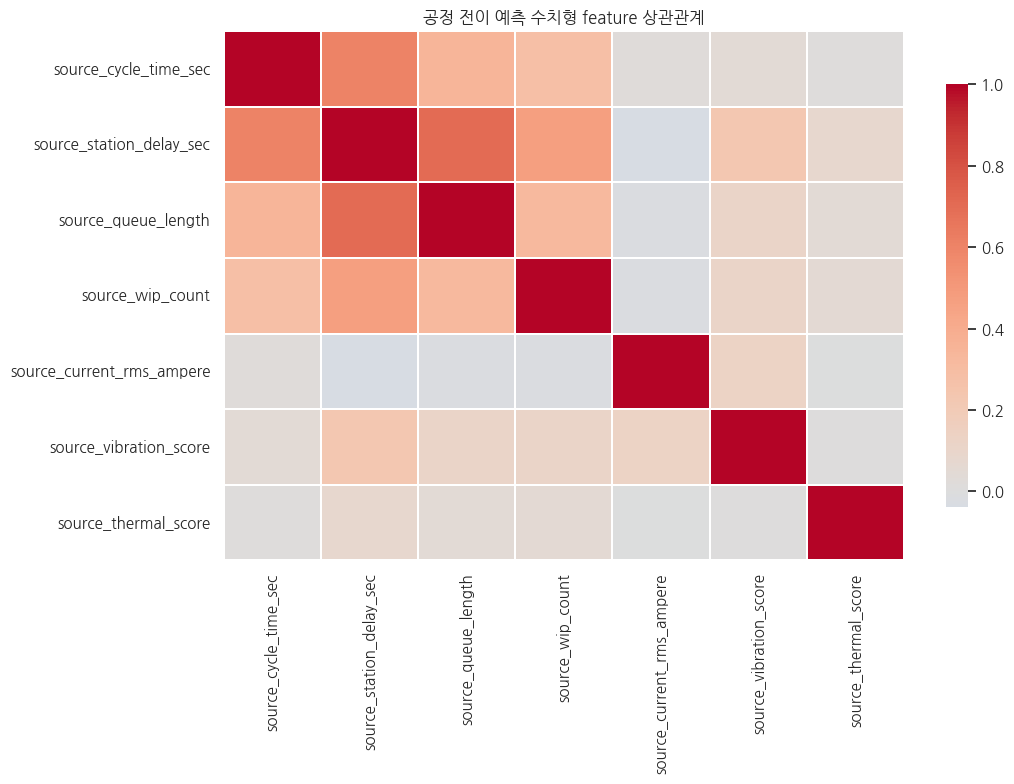


[press_to_body] lightweight CV tuning: 3 trials x 3 folds
  trial 1: CV PR-AUC=0.2900, Recall=0.9990, F1=0.3569, elapsed=1.0s
  trial 2: CV PR-AUC=0.2825, Recall=0.9927, F1=0.3573, elapsed=1.0s
  trial 3: CV PR-AUC=0.2841, Recall=0.9976, F1=0.3568, elapsed=1.0s
재현율(Recall): 0.6833
정밀도(Precision): 0.2580
F1 Score: 0.3745
PR-AUC: 0.3004
임계값(Threshold): 0.4377


,지표,값
0,정확도(Accuracy),0.504583
1,정밀도(Precision),0.257971
2,재현율(Recall),0.683301
3,F1 Score,0.374540
4,ROC-AUC,0.591590
5,PR-AUC,0.300385
6,오탐률(False Positive Rate),0.544971
7,임계값(Threshold),0.437682


,예측 정상(0),예측 불량(1)
실제 정상(0),855,1024
실제 불량(1),165,356


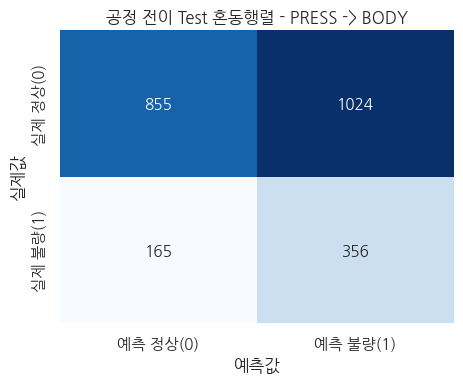


[body_to_paint] lightweight CV tuning: 3 trials x 3 folds
  trial 1: CV PR-AUC=0.2841, Recall=0.9995, F1=0.3617, elapsed=0.8s
  trial 2: CV PR-AUC=0.2739, Recall=0.9915, F1=0.3632, elapsed=1.0s
  trial 3: CV PR-AUC=0.2789, Recall=1.0000, F1=0.3613, elapsed=1.1s
재현율(Recall): 0.6341
정밀도(Precision): 0.2513
F1 Score: 0.3600
PR-AUC: 0.2951
임계값(Threshold): 0.4447


,지표,값
0,정확도(Accuracy),0.499167
1,정밀도(Precision),0.251301
2,재현율(Recall),0.634146
3,F1 Score,0.359957
4,ROC-AUC,0.581338
5,PR-AUC,0.295122
6,오탐률(False Positive Rate),0.539368
7,임계값(Threshold),0.444744


,예측 정상(0),예측 불량(1)
실제 정상(0),860,1007
실제 불량(1),195,338


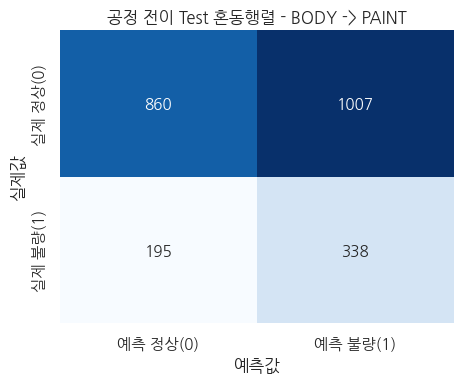


[paint_to_assembly] lightweight CV tuning: 3 trials x 3 folds
  trial 1: CV PR-AUC=0.2310, Recall=0.9960, F1=0.3445, elapsed=1.6s
  trial 2: CV PR-AUC=0.2256, Recall=0.9965, F1=0.3447, elapsed=1.0s
  trial 3: CV PR-AUC=0.2247, Recall=0.9950, F1=0.3446, elapsed=1.1s
재현율(Recall): 0.5776
정밀도(Precision): 0.1856
F1 Score: 0.2810
PR-AUC: 0.1844
임계값(Threshold): 0.4600


,지표,값
0,정확도(Accuracy),0.460417
1,정밀도(Precision),0.185620
2,재현율(Recall),0.577626
3,F1 Score,0.280955
4,ROC-AUC,0.507275
5,PR-AUC,0.184449
6,오탐률(False Positive Rate),0.565749
7,임계값(Threshold),0.460019


,예측 정상(0),예측 불량(1)
실제 정상(0),852,1110
실제 불량(1),185,253


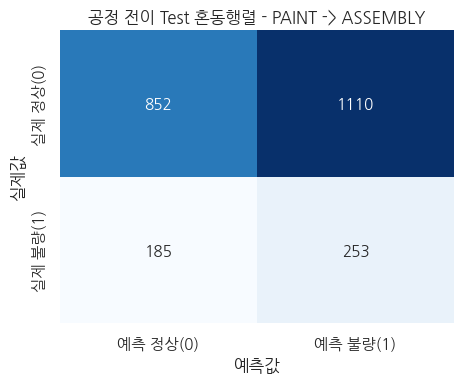

,model_key,trial_no,cv_pr_auc,cv_recall,cv_precision,cv_f1,cv_accuracy,cv_threshold,elapsed_sec,params
0,body_to_paint,1,0.284062,0.999527,0.220817,0.361722,0.223229,0.143963,0.842512,"{'model__subsample': 0.95, 'model__reg_lambda'..."
1,body_to_paint,3,0.278926,1.000000,0.220507,0.361337,0.221562,0.091514,1.105790,"{'model__subsample': 0.95, 'model__reg_lambda'..."
2,body_to_paint,2,0.273898,0.991489,0.222351,0.363213,0.234271,0.115225,1.001900,"{'model__subsample': 0.85, 'model__reg_lambda'..."
3,paint_to_assembly,1,0.230985,0.995966,0.208272,0.344501,0.217083,0.202340,1.578503,"{'model__subsample': 0.95, 'model__reg_lambda'..."
4,paint_to_assembly,2,0.225575,0.996470,0.208419,0.344734,0.217500,0.134790,1.047794,"{'model__subsample': 0.85, 'model__reg_lambda'..."
5,paint_to_assembly,3,0.224656,0.994957,0.208365,0.344569,0.218125,0.161553,1.124835,"{'model__subsample': 0.95, 'model__reg_lambda'..."
6,press_to_body,1,0.290033,0.999033,0.217283,0.356935,0.224167,0.180116,0.991396,"{'model__subsample': 0.95, 'model__reg_lambda'..."
7,press_to_body,3,0.284147,0.997584,0.217244,0.356788,0.224792,0.137241,1.006999,"{'model__subsample': 0.95, 'model__reg_lambda'..."
8,press_to_body,2,0.282452,0.992749,0.217845,0.357285,0.230208,0.134730,1.049339,"{'model__subsample': 0.85, 'model__reg_lambda'..."


,모델 키,소스 공정,타깃 공정,선택 파라미터,train_threshold,train_pr_auc,train_roc_auc,Train 정확도,Train 정밀도,Train 재현율,Train F1,train_false_positive_rate,train_tn,train_fp,train_fn,train_tp,임계값,Test PR-AUC,test_roc_auc,Test 정확도,Test 정밀도,Test 재현율,Test F1,Test 오탐률,test_tn,test_fp,test_fn,test_tp
0,press_to_body,PRESS,BODY,"{'model__subsample': 0.95, 'model__reg_lambda'...",0.437682,0.491504,0.796379,0.605833,0.342342,0.899952,0.496004,0.474970,3954,3577,207,1862,0.437682,0.300385,0.591590,0.504583,0.257971,0.683301,0.374540,0.544971,855,1024,165,356
1,body_to_paint,BODY,PAINT,"{'model__subsample': 0.95, 'model__reg_lambda'...",0.444744,0.496058,0.784340,0.604688,0.344611,0.881741,0.495547,0.473551,3941,3545,250,1864,0.444744,0.295122,0.581338,0.499167,0.251301,0.634146,0.359957,0.539368,860,1007,195,338
2,paint_to_assembly,PAINT,ASSEMBLY,"{'model__subsample': 0.95, 'model__reg_lambda'...",0.460019,0.492547,0.794082,0.590521,0.322845,0.895108,0.474535,0.488775,3894,3723,208,1775,0.460019,0.184449,0.507275,0.460417,0.185620,0.577626,0.280955,0.565749,852,1110,185,253


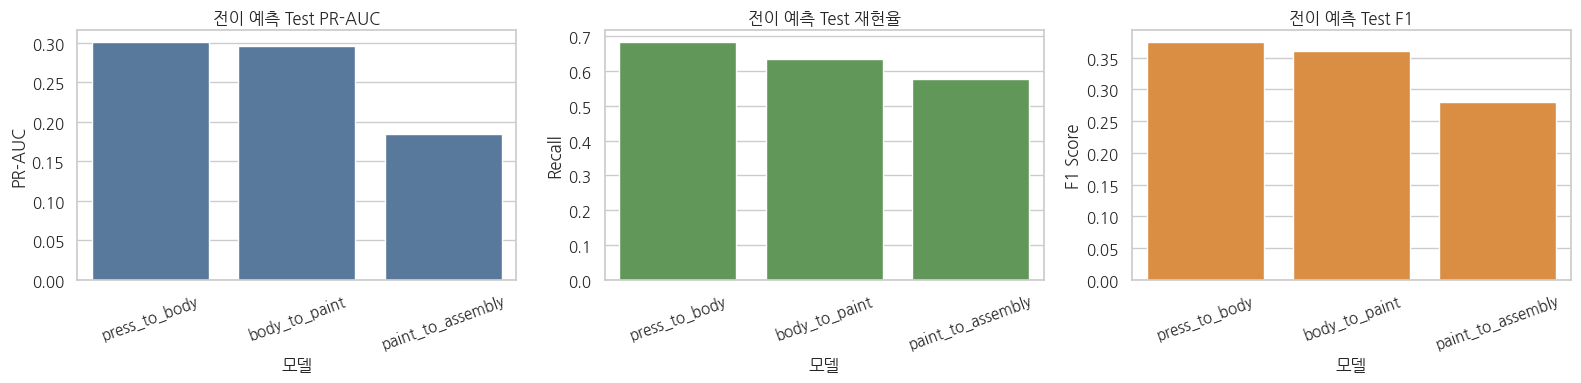

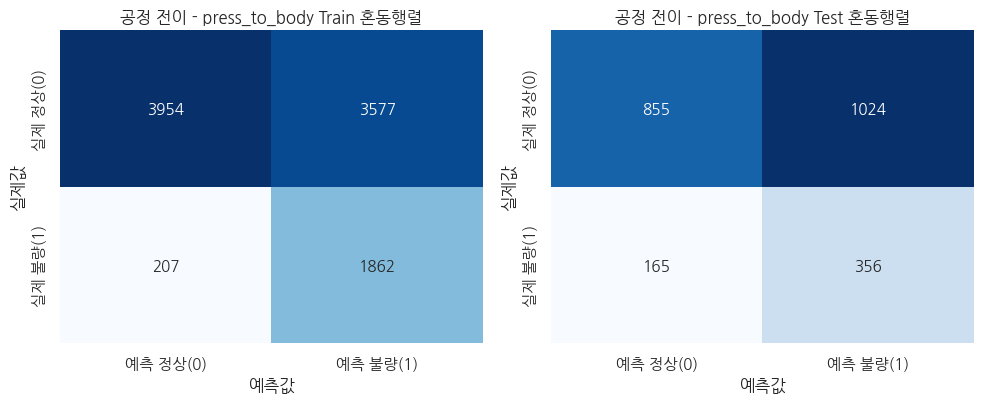

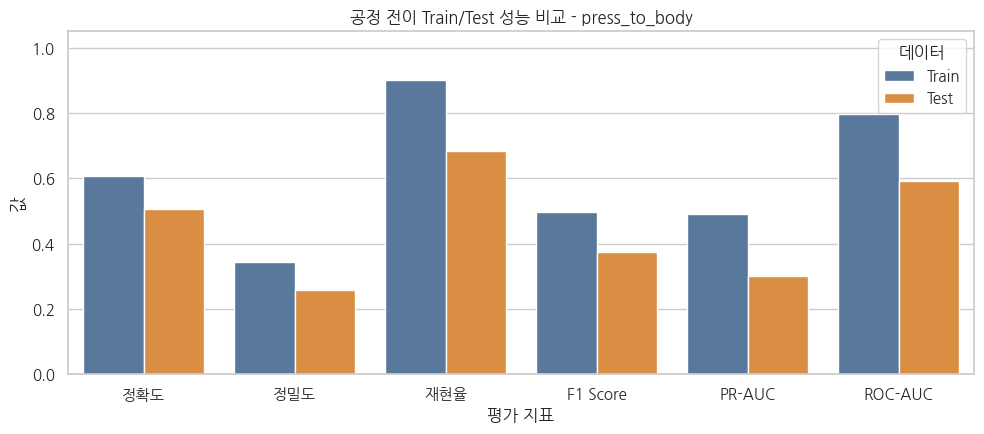

split,metric,Test,Train
0,F1 Score,0.374540,0.496004
1,PR-AUC,0.300385,0.491504
2,ROC-AUC,0.591590,0.796379
3,재현율,0.683301,0.899952
4,정밀도,0.257971,0.342342
5,정확도,0.504583,0.605833


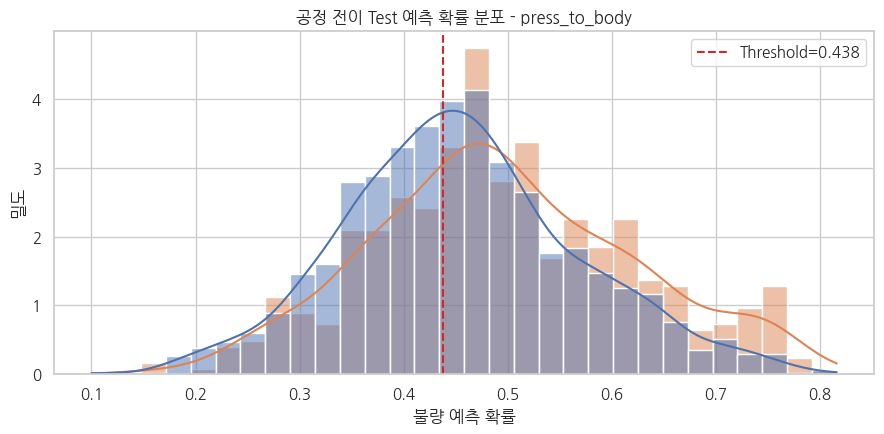

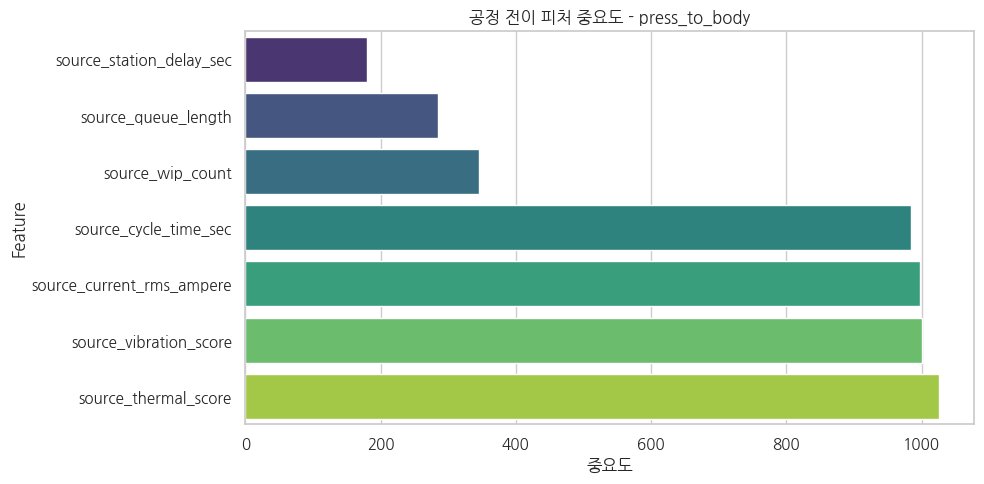

,feature,importance,importance_ratio
0,source_thermal_score,1026.0,0.212863
1,source_vibration_score,1001.0,0.207676
2,source_current_rms_ampere,998.0,0.207054
3,source_cycle_time_sec,984.0,0.204149
4,source_wip_count,346.0,0.071784
5,source_queue_length,285.0,0.059129
6,source_station_delay_sec,180.0,0.037344


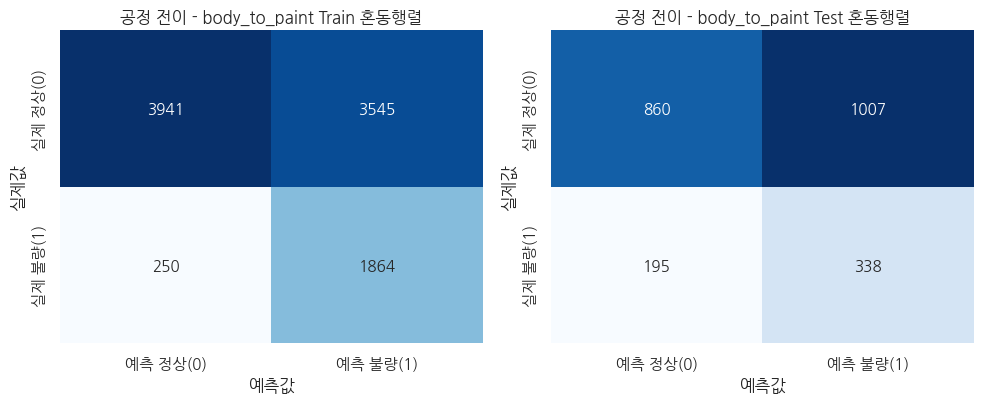

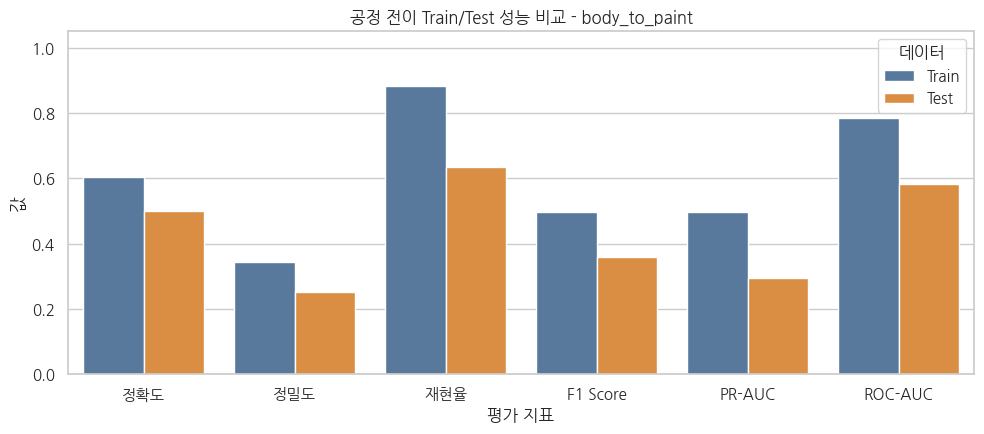

split,metric,Test,Train
0,F1 Score,0.359957,0.495547
1,PR-AUC,0.295122,0.496058
2,ROC-AUC,0.581338,0.784340
3,재현율,0.634146,0.881741
4,정밀도,0.251301,0.344611
5,정확도,0.499167,0.604688


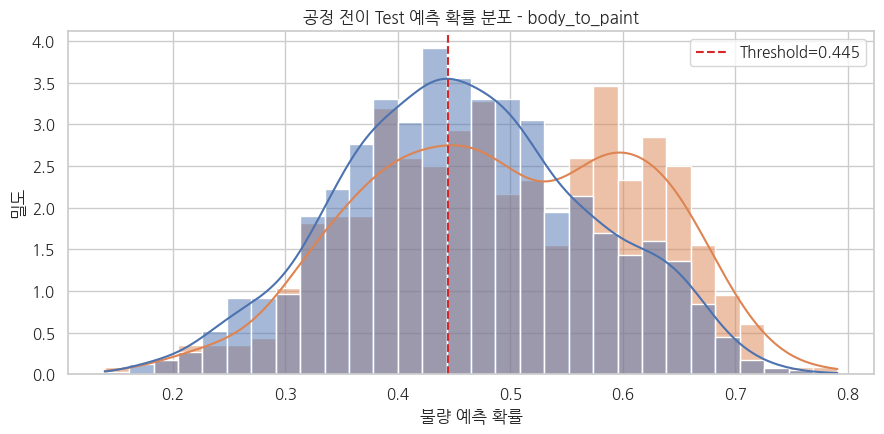

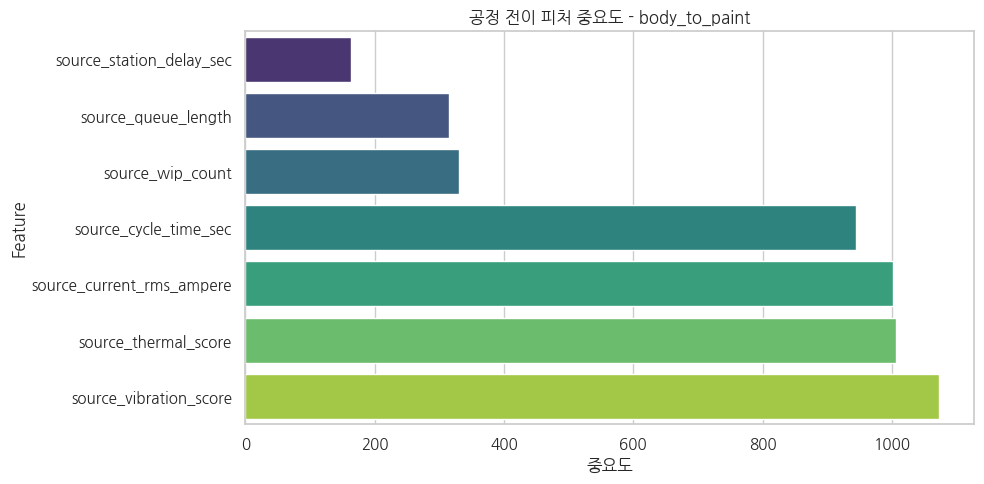

,feature,importance,importance_ratio
0,source_vibration_score,1073.0,0.221969
1,source_thermal_score,1006.0,0.208109
2,source_current_rms_ampere,1001.0,0.207075
3,source_cycle_time_sec,944.0,0.195283
4,source_wip_count,331.0,0.068473
5,source_queue_length,315.0,0.065163
6,source_station_delay_sec,164.0,0.033926


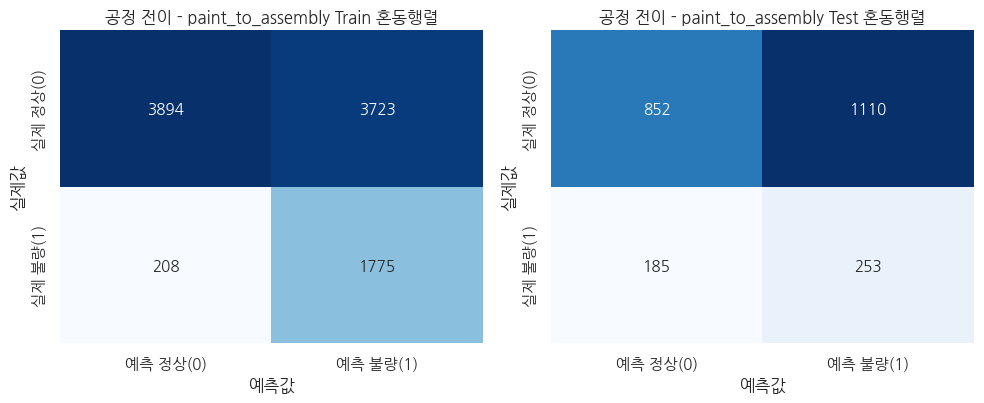

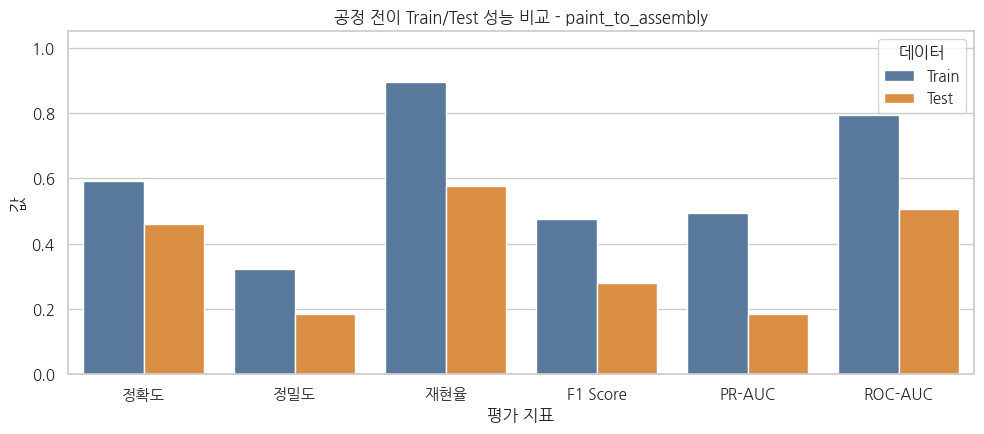

split,metric,Test,Train
0,F1 Score,0.280955,0.474535
1,PR-AUC,0.184449,0.492547
2,ROC-AUC,0.507275,0.794082
3,재현율,0.577626,0.895108
4,정밀도,0.185620,0.322845
5,정확도,0.460417,0.590521


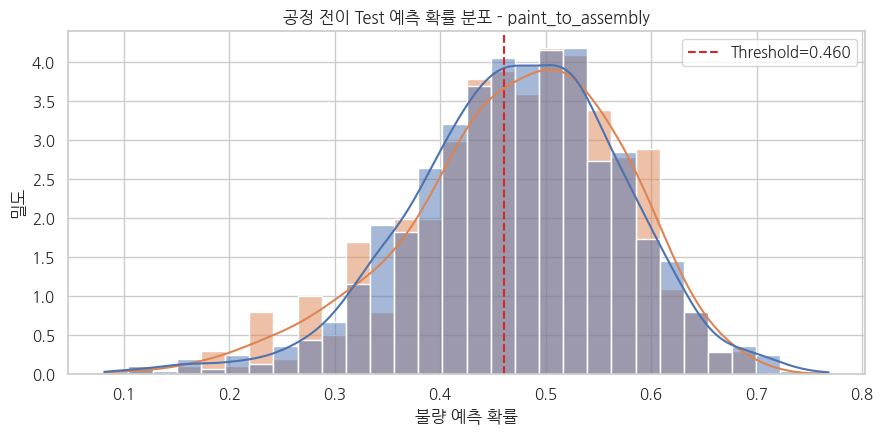

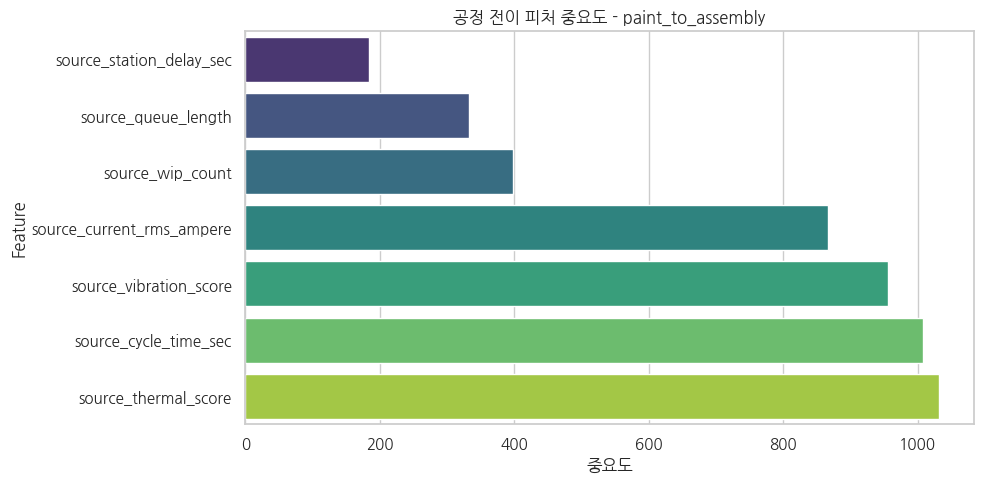

,feature,importance,importance_ratio
0,source_thermal_score,1032.0,0.216035
1,source_cycle_time_sec,1008.0,0.211011
2,source_vibration_score,956.0,0.200126
3,source_current_rms_ampere,867.0,0.181495
4,source_wip_count,398.0,0.083316
5,source_queue_length,332.0,0.069500
6,source_station_delay_sec,184.0,0.038518


,car_master_id,source_event_id,target_event_id,source_process_code,target_process_code,model_key,target_defect_probability,threshold,predicted_target_defect_yn,risk_grade,target_actual_yn
1816,11417,EVT-20260618-045665,EVT-20260618-045666,PRESS,BODY,press_to_body,0.816156,0.437682,1,HIGH,0
1805,11406,EVT-20260618-045621,EVT-20260618-045622,PRESS,BODY,press_to_body,0.814475,0.437682,1,HIGH,1
355,9956,EVT-20260617-039821,EVT-20260617-039822,PRESS,BODY,press_to_body,0.796522,0.437682,1,HIGH,0
348,9949,EVT-20260617-039793,EVT-20260617-039794,PRESS,BODY,press_to_body,0.795205,0.437682,1,HIGH,0
4730,11931,EVT-20260618-047722,EVT-20260618-047723,BODY,PAINT,body_to_paint,0.790645,0.444744,1,HIGH,0
2470,9671,EVT-20260617-038682,EVT-20260617-038683,BODY,PAINT,body_to_paint,0.788088,0.444744,1,HIGH,1
224,9825,EVT-20260617-039297,EVT-20260617-039298,PRESS,BODY,press_to_body,0.778944,0.437682,1,HIGH,1
56,9657,EVT-20260617-038625,EVT-20260617-038626,PRESS,BODY,press_to_body,0.773686,0.437682,1,HIGH,1
35,9636,EVT-20260617-038541,EVT-20260617-038542,PRESS,BODY,press_to_body,0.772719,0.437682,1,HIGH,1
43,9644,EVT-20260617-038573,EVT-20260617-038574,PRESS,BODY,press_to_body,0.769506,0.437682,1,HIGH,0


In [11]:
TRANSFER_TARGET = "target_defect_yn"
TRANSFER_LEAKAGE_COLS = [
    TRANSFER_TARGET,
    "source_defect_yn",
    "target_defect_reason",
    "target_event_json",
    "target_defect_probability",
    "predicted_target_defect_yn",
    "target_actual_yn",
]
TRANSFER_EXCLUDE_COLS = [
    "car_master_id",
    "source_event_id",
    "target_event_id",
    "source_process_code",
    "target_process_code",
    "source_event_json",
    "dataset_split",
] + TRANSFER_LEAKAGE_COLS

transition_feature_cols = select_model_features(
    transfer_train_raw,
    TRANSFER_TARGET,
    TRANSFER_EXCLUDE_COLS,
    TRANSFER_LEAKAGE_COLS,
    context="공정 전이 예측",
)
transition_feature_cols = drop_suspicious_features(transfer_train_raw, TRANSFER_TARGET, transition_feature_cols, context="공정 전이 예측")
ensure_feature_columns_exist(transfer_test_raw, transition_feature_cols, context="공정 전이 예측")
print("공정 전이 예측 feature 수:", len(transition_feature_cols))
print("공정 전이 예측 feature:", transition_feature_cols)

plot_class_distribution(transfer_train_raw, transfer_test_raw, TRANSFER_TARGET, "공정 전이 예측")
display(pd.crosstab([transfer_train_raw["source_process_code"], transfer_train_raw["target_process_code"]], transfer_train_raw[TRANSFER_TARGET], normalize="index").rename(columns={0: "정상 비율", 1: "전이 양성 비율"}))
plot_feature_distribution_grid(transfer_train_raw, transition_feature_cols, TRANSFER_TARGET, "공정 전이 예측 주요 feature 분포", max_features=12)
plot_numeric_correlation_heatmap(transfer_train_raw, transition_feature_cols, "공정 전이 예측 수치형 feature 상관관계", max_features=12)


TRANSITION_PARAM_DISTRIBUTIONS = {
    "model__n_estimators": [160, 220, 280],
    "model__learning_rate": [0.035, 0.045, 0.06],
    "model__num_leaves": [11, 15, 23],
    "model__min_child_samples": [40, 60, 90],
    "model__subsample": [0.75, 0.85, 0.95],
    "model__colsample_bytree": [0.70, 0.80, 0.90],
    "model__reg_lambda": [4.0, 8.0, 12.0],
}


def make_transition_model(train_df: pd.DataFrame, feature_cols: list[str], scale_pos_weight: float):
    return Pipeline([
        ("preprocess", make_preprocessor(train_df, feature_cols, scale_numeric=False)),
        ("model", lgb.LGBMClassifier(
            objective="binary",
            n_estimators=220,
            learning_rate=0.045,
            num_leaves=15,
            min_child_samples=60,
            subsample=0.85,
            colsample_bytree=0.75,
            reg_lambda=8.0,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1,
        )),
    ])


def tune_transition_model_cv(model_key: str, train_flow: pd.DataFrame, feature_cols: list[str], target_col: str, scale_pos_weight: float):
    X = train_flow[feature_cols]
    y = train_flow[target_col].astype(int)
    X_tune, y_tune = make_tuning_sample(X, y, MAX_TUNING_ROWS)
    candidates = sample_param_candidates(TRANSITION_PARAM_DISTRIBUTIONS, TUNING_TRIALS_PER_MODEL, RANDOM_STATE)
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    best_row = None
    best_score = (-np.inf, -np.inf, -np.inf)
    print(f"\n[{model_key}] lightweight CV tuning: {len(candidates)} trials x {CV_FOLDS} folds")
    for trial_no, params in enumerate(candidates, start=1):
        fold_metrics = []
        started_at = time.perf_counter()
        for train_idx, valid_idx in cv.split(X_tune, y_tune):
            X_fold_train = X_tune.iloc[train_idx]
            y_fold_train = y_tune.iloc[train_idx]
            X_fold_valid = X_tune.iloc[valid_idx]
            y_fold_valid = y_tune.iloc[valid_idx]
            estimator = make_transition_model(train_flow, feature_cols, scale_pos_weight)
            estimator.set_params(**params)
            estimator.fit(X_fold_train, y_fold_train)
            valid_proba = predict_positive_proba(estimator, X_fold_valid)
            threshold = find_recall_priority_threshold(y_fold_valid, valid_proba, min_recall=0.60, min_precision=0.20)
            fold_metrics.append(compute_metrics(y_fold_valid, valid_proba, threshold))
        elapsed_sec = time.perf_counter() - started_at
        row = {
            "model_key": model_key,
            "trial_no": trial_no,
            "params": params,
            "cv_pr_auc": float(np.mean([m["pr_auc"] for m in fold_metrics])),
            "cv_recall": float(np.mean([m["recall"] for m in fold_metrics])),
            "cv_precision": float(np.mean([m["precision"] for m in fold_metrics])),
            "cv_f1": float(np.mean([m["f1"] for m in fold_metrics])),
            "cv_accuracy": float(np.mean([m["accuracy"] for m in fold_metrics])),
            "cv_threshold": float(np.mean([m["threshold"] for m in fold_metrics])),
            "elapsed_sec": elapsed_sec,
        }
        rows.append(row)
        score = (row["cv_pr_auc"], row["cv_recall"], row["cv_f1"])
        if score > best_score:
            best_score = score
            best_row = row
        print(f"  trial {trial_no}: CV PR-AUC={row['cv_pr_auc']:.4f}, Recall={row['cv_recall']:.4f}, F1={row['cv_f1']:.4f}, elapsed={elapsed_sec:.1f}s")
    return best_row, rows


transition_models = {}
transition_metadata = {}
transition_metric_rows = []
transition_cv_rows = []
transition_prediction_frames = []
transition_confusion_tables = {}
transition_train_confusion_tables = {}
transition_proba_by_model = {}
transition_train_proba_by_model = {}
transition_y_true_by_model = {}
transition_y_train_by_model = {}

for source_process, target_process in TRANSFER_FLOW_ORDER:
    model_key = f"{source_process.lower()}_to_{target_process.lower()}"
    train_flow = transfer_train_raw[(transfer_train_raw["source_process_code"] == source_process) & (transfer_train_raw["target_process_code"] == target_process)].copy()
    test_flow = transfer_test_raw[(transfer_test_raw["source_process_code"] == source_process) & (transfer_test_raw["target_process_code"] == target_process)].copy()
    if train_flow.empty or test_flow.empty:
        print(f"{model_key}: 학습 또는 테스트 데이터가 없어 건너뜁니다.")
        continue
    X_train_flow = train_flow[transition_feature_cols]
    y_train_flow = train_flow[TRANSFER_TARGET].astype(int)
    X_test_flow = test_flow[transition_feature_cols]
    y_test_flow = test_flow[TRANSFER_TARGET].astype(int)
    if y_train_flow.nunique() < 2 or y_test_flow.nunique() < 2:
        print(f"{model_key}: 한 클래스만 존재해 건너뜁니다.")
        continue
    spw = scale_pos_weight_for(y_train_flow)
    best_params = {}
    if ENABLE_HYPERPARAMETER_TUNING:
        best_row, rows = tune_transition_model_cv(model_key, train_flow, transition_feature_cols, TRANSFER_TARGET, spw)
        transition_cv_rows.extend(rows)
        best_params = best_row["params"] if best_row else {}
    flow_model = make_transition_model(train_flow, transition_feature_cols, spw)
    flow_model.set_params(**best_params)
    flow_model.fit(X_train_flow, y_train_flow)
    train_proba = predict_positive_proba(flow_model, X_train_flow)
    test_proba = predict_positive_proba(flow_model, X_test_flow)
    threshold = find_recall_priority_threshold(y_train_flow, train_proba, min_recall=0.60, min_precision=0.20)
    train_metrics = compute_metrics(y_train_flow, train_proba, threshold)
    test_metrics = compute_metrics(y_test_flow, test_proba, threshold)
    _, cm_table = display_confusion_matrix_report(y_test_flow, test_proba, threshold, title=f"공정 전이 Test 혼동행렬 - {source_process} -> {target_process}")
    transition_models[model_key] = flow_model
    transition_train_confusion_tables[model_key] = confusion_matrix_table(train_metrics)
    transition_confusion_tables[model_key] = cm_table
    transition_train_proba_by_model[model_key] = train_proba
    transition_proba_by_model[model_key] = test_proba
    transition_y_train_by_model[model_key] = y_train_flow
    transition_y_true_by_model[model_key] = y_test_flow
    transition_metadata[model_key] = {"source_process_code": source_process, "target_process_code": target_process, "threshold": threshold, "feature_columns": transition_feature_cols, "scale_pos_weight": spw, "best_params": best_params}
    transition_metric_rows.append({
        "model_key": model_key,
        "source_process_code": source_process,
        "target_process_code": target_process,
        "best_params": best_params,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"test_{k}": v for k, v in test_metrics.items()},
    })
    pred_frame = test_flow[["car_master_id", "source_event_id", "target_event_id", "source_process_code", "target_process_code"]].copy()
    pred_frame["model_key"] = model_key
    pred_frame["target_defect_probability"] = test_proba
    pred_frame["threshold"] = threshold
    pred_frame["predicted_target_defect_yn"] = (test_proba >= threshold).astype(int)
    pred_frame["risk_grade"] = pred_frame["target_defect_probability"].map(risk_grade)
    pred_frame["target_actual_yn"] = y_test_flow.to_numpy()
    transition_prediction_frames.append(pred_frame)

transition_cv_results = pd.DataFrame(transition_cv_rows)
if not transition_cv_results.empty:
    display(
        transition_cv_results.sort_values(["model_key", "cv_pr_auc", "cv_recall", "cv_f1"], ascending=[True, False, False, False])
        [["model_key", "trial_no", "cv_pr_auc", "cv_recall", "cv_precision", "cv_f1", "cv_accuracy", "cv_threshold", "elapsed_sec", "params"]]
        .reset_index(drop=True)
    )

transition_model_metrics = pd.DataFrame(transition_metric_rows).sort_values(["test_pr_auc", "test_recall", "test_f1"], ascending=False).reset_index(drop=True) if transition_metric_rows else pd.DataFrame()
transition_predictions = pd.concat(transition_prediction_frames, ignore_index=True) if transition_prediction_frames else pd.DataFrame()
if not transition_model_metrics.empty:
    display(transition_model_metrics.rename(columns={
        "model_key": "모델 키",
        "source_process_code": "소스 공정",
        "target_process_code": "타깃 공정",
        "best_params": "선택 파라미터",
        "train_f1": "Train F1",
        "test_f1": "Test F1",
        "train_recall": "Train 재현율",
        "test_recall": "Test 재현율",
        "train_precision": "Train 정밀도",
        "test_precision": "Test 정밀도",
        "train_accuracy": "Train 정확도",
        "test_accuracy": "Test 정확도",
        "test_pr_auc": "Test PR-AUC",
        "test_false_positive_rate": "Test 오탐률",
        "test_threshold": "임계값",
    }))
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    sns.barplot(data=transition_model_metrics, x="model_key", y="test_pr_auc", ax=axes[0], color="#4C78A8")
    axes[0].set_title("전이 예측 Test PR-AUC")
    axes[0].set_xlabel("모델")
    axes[0].set_ylabel("PR-AUC")
    axes[0].tick_params(axis="x", rotation=20)
    sns.barplot(data=transition_model_metrics, x="model_key", y="test_recall", ax=axes[1], color="#59A14F")
    axes[1].set_title("전이 예측 Test 재현율")
    axes[1].set_xlabel("모델")
    axes[1].set_ylabel("Recall")
    axes[1].tick_params(axis="x", rotation=20)
    sns.barplot(data=transition_model_metrics, x="model_key", y="test_f1", ax=axes[2], color="#F28E2B")
    axes[2].set_title("전이 예측 Test F1")
    axes[2].set_xlabel("모델")
    axes[2].set_ylabel("F1 Score")
    axes[2].tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()

    for model_key in transition_model_metrics["model_key"]:
        threshold = transition_metadata[model_key]["threshold"]
        train_metrics, test_metrics = plot_train_test_confusion(
            transition_y_train_by_model[model_key],
            transition_train_proba_by_model[model_key],
            transition_y_true_by_model[model_key],
            transition_proba_by_model[model_key],
            threshold,
            f"공정 전이 - {model_key}",
        )
        plot_train_test_metric_comparison(train_metrics, test_metrics, f"공정 전이 Train/Test 성능 비교 - {model_key}")
        plot_probability_distribution(transition_y_true_by_model[model_key], transition_proba_by_model[model_key], threshold, f"공정 전이 Test 예측 확률 분포 - {model_key}")
        importance = model_feature_importance(transition_models[model_key])
        plot_model_feature_importance(importance, f"공정 전이 피처 중요도 - {model_key}", top_n=15)

if not transition_predictions.empty:
    display(transition_predictions.sort_values("target_defect_probability", ascending=False).head(30))

## 7. SHAP 기반 전이 위험 분석 및 Kafka 분석 이벤트

**셀 설명**

전이 예측 모델별 SHAP 중요도를 계산하고, 화면/API에서 사용할 수 있는 분석 이벤트 형태로 변환합니다.

,feature,mean_abs_shap,model_key,source_process_code,target_process_code
0,source_cycle_time_sec,0.194787,press_to_body,PRESS,BODY
1,source_current_rms_ampere,0.177804,press_to_body,PRESS,BODY
2,source_queue_length,0.157906,press_to_body,PRESS,BODY
3,source_vibration_score,0.097177,press_to_body,PRESS,BODY
4,source_thermal_score,0.091699,press_to_body,PRESS,BODY
5,source_wip_count,0.053012,press_to_body,PRESS,BODY
6,source_station_delay_sec,0.036352,press_to_body,PRESS,BODY
7,source_cycle_time_sec,0.189979,body_to_paint,BODY,PAINT
8,source_vibration_score,0.175717,body_to_paint,BODY,PAINT
9,source_thermal_score,0.099140,body_to_paint,BODY,PAINT


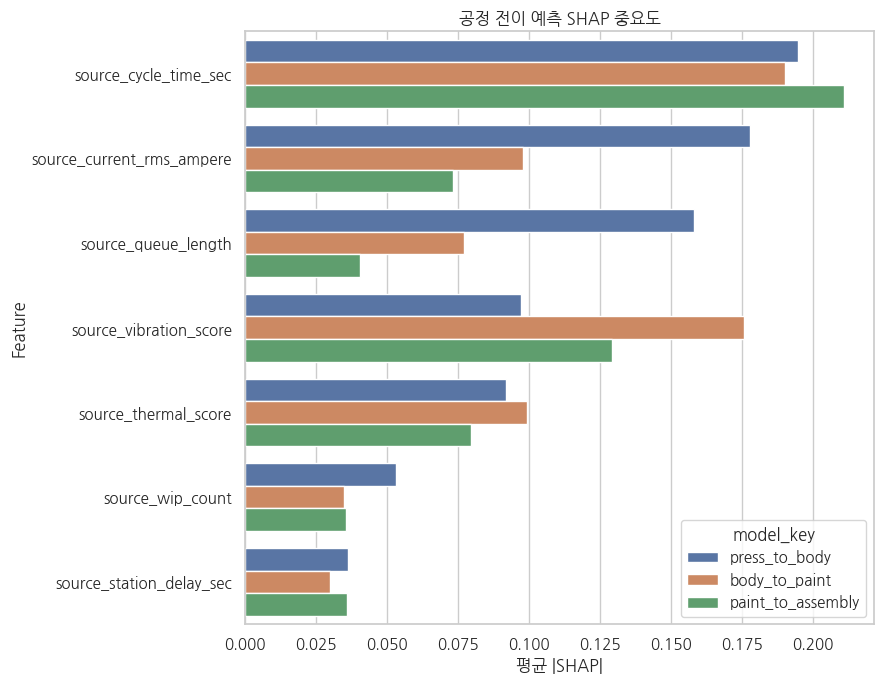

kafka event examples: 500
[
  {
    "eventType": "DEFECT_TRANSFER_PREDICTION",
    "carMasterId": 11417,
    "sourceEventId": "EVT-20260618-045665",
    "targetEventId": "EVT-20260618-045666",
    "sourceProcessCode": "PRESS",
    "targetProcessCode": "BODY",
    "targetDefectProbability": 0.8161559491328145,
    "threshold": 0.4376819769807411,
    "predictedTargetDefectYn": 1,
    "riskGrade": "HIGH",
    "mainCause": "source_cycle_time_sec",
    "modelKey": "press_to_body",
    "predictedAt": "2026-06-27T06:42:38.645689+00:00"
  },
  {
    "eventType": "DEFECT_TRANSFER_PREDICTION",
    "carMasterId": 11406,
    "sourceEventId": "EVT-20260618-045621",
    "targetEventId": "EVT-20260618-045622",
    "sourceProcessCode": "PRESS",
    "targetProcessCode": "BODY",
    "targetDefectProbability": 0.81447506053072,
    "threshold": 0.4376819769807411,
    "predictedTargetDefectYn": 1,
    "riskGrade": "HIGH",
    "mainCause": "source_cycle_time_sec",
    "modelKey": "press_to_body",
    "pr

In [12]:
transition_shap_importance_rows = []
for model_key, model in transition_models.items():
    meta = transition_metadata[model_key]
    flow_test = transfer_test_raw[(transfer_test_raw["source_process_code"] == meta["source_process_code"]) & (transfer_test_raw["target_process_code"] == meta["target_process_code"])]
    importance, _ = compute_shap_importance(model, flow_test[transition_feature_cols], sample_size=500)
    importance["model_key"] = model_key
    importance["source_process_code"] = meta["source_process_code"]
    importance["target_process_code"] = meta["target_process_code"]
    transition_shap_importance_rows.append(importance)

transition_shap_importance = pd.concat(transition_shap_importance_rows, ignore_index=True) if transition_shap_importance_rows else pd.DataFrame()
global_top_cause = {}
if not transition_shap_importance.empty:
    global_top_cause = transition_shap_importance.sort_values(["model_key", "mean_abs_shap"], ascending=[True, False]).groupby("model_key").first()["feature"].to_dict()
    display(transition_shap_importance.groupby("model_key").head(10))
    plt.figure(figsize=(9, 7))
    sns.barplot(data=transition_shap_importance.groupby("model_key").head(8), x="mean_abs_shap", y="feature", hue="model_key")
    plt.title("공정 전이 예측 SHAP 중요도")
    plt.xlabel("평균 |SHAP|")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

predicted_at = datetime.now(timezone.utc).isoformat()
if not transition_predictions.empty:
    transition_predictions["main_cause"] = transition_predictions["model_key"].map(global_top_cause).fillna("not_available")
    transition_predictions["predicted_at"] = predicted_at

kafka_analysis_events = []
for _, row in transition_predictions.sort_values("target_defect_probability", ascending=False).head(500).iterrows():
    kafka_analysis_events.append({
        "eventType": "DEFECT_TRANSFER_PREDICTION",
        "carMasterId": int(row["car_master_id"]),
        "sourceEventId": str(row["source_event_id"]),
        "targetEventId": str(row["target_event_id"]),
        "sourceProcessCode": str(row["source_process_code"]),
        "targetProcessCode": str(row["target_process_code"]),
        "targetDefectProbability": float(row["target_defect_probability"]),
        "threshold": float(row["threshold"]),
        "predictedTargetDefectYn": int(row["predicted_target_defect_yn"]),
        "riskGrade": str(row["risk_grade"]),
        "mainCause": str(row["main_cause"]),
        "modelKey": str(row["model_key"]),
        "predictedAt": predicted_at,
    })
print("kafka event examples:", len(kafka_analysis_events))
print(json.dumps(kafka_analysis_events[:3], ensure_ascii=False, indent=2))

## 8. 모델/분석 산출물 저장

**셀 설명**

학습된 모델, feature 목록, metric, 혼동행렬, SHAP 결과, 전이 모델 metadata를 파일로 저장합니다.

In [13]:
def to_builtin(value):
    if isinstance(value, dict):
        return {k: to_builtin(v) for k, v in value.items()}
    if isinstance(value, list):
        return [to_builtin(v) for v in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, pd.DataFrame):
        return value.to_dict(orient="records")
    return value


selected_model_path = OUTPUT_DIR / "selected_defect_detector.joblib"
candidate_models_path = OUTPUT_DIR / "candidate_defect_models.joblib"
feature_path = OUTPUT_DIR / "defect_model_features.json"
metrics_path = OUTPUT_DIR / "defect_model_metrics.json"
comparison_path = OUTPUT_DIR / "defect_model_comparison.json"
cv_results_path = OUTPUT_DIR / "defect_model_cv_results.json"
confusion_matrix_path = OUTPUT_DIR / "defect_model_confusion_matrix.json"
all_confusion_matrices_path = OUTPUT_DIR / "defect_model_confusion_matrices_by_model.json"
train_confusion_matrices_path = OUTPUT_DIR / "defect_model_train_confusion_matrices_by_model.json"
shap_importance_path = OUTPUT_DIR / "defect_shap_importance.json"
feature_importance_path = OUTPUT_DIR / "defect_model_feature_importance.json"
transition_models_path = OUTPUT_DIR / "adjacent_transfer_models.joblib"
transition_metadata_path = OUTPUT_DIR / "adjacent_transfer_model_metadata.json"
transition_metrics_path = OUTPUT_DIR / "adjacent_transfer_model_metrics.json"
transition_confusion_path = OUTPUT_DIR / "adjacent_transfer_confusion_matrices.json"
transition_train_confusion_path = OUTPUT_DIR / "adjacent_transfer_train_confusion_matrices.json"
transition_shap_path = OUTPUT_DIR / "adjacent_transfer_shap_importance.json"
transition_cv_results_path = OUTPUT_DIR / "adjacent_transfer_cv_results.json"
kafka_events_path = OUTPUT_DIR / "defect_transfer_kafka_analysis_events.jsonl"
schema_path = OUTPUT_DIR / "event_json_inference_schema.json"

joblib.dump(selected_event_model, selected_model_path)
joblib.dump(event_candidate_models, candidate_models_path)
joblib.dump(transition_models, transition_models_path)
feature_path.write_text(json.dumps(event_feature_cols, ensure_ascii=False, indent=2), encoding="utf-8")
metrics_payload = {
    "selected_model_name": selected_event_model_name,
    "threshold": selected_event_threshold,
    "train_metrics": compute_metrics(y_event_train, event_train_proba, selected_event_threshold),
    "test_metrics": compute_metrics(y_event_test, event_test_proba, selected_event_threshold),
    "train_rows": int(len(defect_train)),
    "test_rows": int(len(defect_test)),
    "positive_ratio_train": float(y_event_train.mean()),
    "created_at": datetime.now(timezone.utc).isoformat(),
}
metrics_path.write_text(json.dumps(to_builtin(metrics_payload), ensure_ascii=False, indent=2), encoding="utf-8")
comparison_path.write_text(event_model_comparison.to_json(orient="records", force_ascii=False, indent=2), encoding="utf-8")
if "event_cv_results" in globals() and not event_cv_results.empty:
    cv_results_path.write_text(event_cv_results.to_json(orient="records", force_ascii=False, indent=2), encoding="utf-8")
if "transition_cv_results" in globals() and not transition_cv_results.empty:
    transition_cv_results_path.write_text(transition_cv_results.to_json(orient="records", force_ascii=False, indent=2), encoding="utf-8")
confusion_matrix_path.write_text(event_confusion_matrix_table.to_json(orient="split", force_ascii=False, indent=2), encoding="utf-8")
if "event_confusion_tables_by_model" in globals():
    all_confusion_matrices_path.write_text(json.dumps({key: table.to_dict(orient="split") for key, table in event_confusion_tables_by_model.items()}, ensure_ascii=False, indent=2), encoding="utf-8")
if "event_train_confusion_tables_by_model" in globals():
    train_confusion_matrices_path.write_text(json.dumps({key: table.to_dict(orient="split") for key, table in event_train_confusion_tables_by_model.items()}, ensure_ascii=False, indent=2), encoding="utf-8")
shap_importance_path.write_text(event_shap_importance.to_json(orient="records", force_ascii=False, indent=2), encoding="utf-8")
feature_importance_path.write_text(event_model_importance.to_json(orient="records", force_ascii=False, indent=2), encoding="utf-8")
transition_metadata_path.write_text(json.dumps(to_builtin(transition_metadata), ensure_ascii=False, indent=2), encoding="utf-8")
transition_metrics_path.write_text(transition_model_metrics.to_json(orient="records", force_ascii=False, indent=2), encoding="utf-8")
transition_confusion_path.write_text(json.dumps({key: table.to_dict(orient="split") for key, table in transition_confusion_tables.items()}, ensure_ascii=False, indent=2), encoding="utf-8")
transition_train_confusion_path.write_text(json.dumps({key: table.to_dict(orient="split") for key, table in transition_train_confusion_tables.items()}, ensure_ascii=False, indent=2), encoding="utf-8")
transition_shap_path.write_text(transition_shap_importance.to_json(orient="records", force_ascii=False, indent=2), encoding="utf-8")
with open(kafka_events_path, "w", encoding="utf-8") as f:
    for event in kafka_analysis_events:
        f.write(json.dumps(to_builtin(event), ensure_ascii=False) + "\n")
schema_payload = {"event_model": {"target_column": EVENT_TARGET, "feature_columns": event_feature_cols, "source_train_csv": str(DEFECT_TRAIN_PATH), "source_test_csv": str(DEFECT_TEST_PATH)}, "transition_model": {"target_column": TRANSFER_TARGET, "feature_columns": transition_feature_cols, "source_train_csv": str(TRANSFER_TRAIN_PATH), "source_test_csv": str(TRANSFER_TEST_PATH)}}
schema_path.write_text(json.dumps(schema_payload, ensure_ascii=False, indent=2), encoding="utf-8")

for path in [
    selected_model_path,
    feature_path,
    metrics_path,
    comparison_path,
    cv_results_path,
    confusion_matrix_path,
    all_confusion_matrices_path,
    shap_importance_path,
    feature_importance_path,
    transition_models_path,
    transition_metadata_path,
    transition_metrics_path,
    transition_confusion_path,
    transition_train_confusion_path,
    transition_shap_path,
    kafka_events_path,
    schema_path,
]:
    if path.exists():
        print(path)

/content/drive/MyDrive/defect_transfer_outputs/selected_defect_detector.joblib
/content/drive/MyDrive/defect_transfer_outputs/defect_model_features.json
/content/drive/MyDrive/defect_transfer_outputs/defect_model_metrics.json
/content/drive/MyDrive/defect_transfer_outputs/defect_model_comparison.json
/content/drive/MyDrive/defect_transfer_outputs/defect_model_cv_results.json
/content/drive/MyDrive/defect_transfer_outputs/defect_model_confusion_matrix.json
/content/drive/MyDrive/defect_transfer_outputs/defect_model_confusion_matrices_by_model.json
/content/drive/MyDrive/defect_transfer_outputs/defect_shap_importance.json
/content/drive/MyDrive/defect_transfer_outputs/defect_model_feature_importance.json
/content/drive/MyDrive/defect_transfer_outputs/adjacent_transfer_models.joblib
/content/drive/MyDrive/defect_transfer_outputs/adjacent_transfer_model_metadata.json
/content/drive/MyDrive/defect_transfer_outputs/adjacent_transfer_model_metrics.json
/content/drive/MyDrive/defect_transfer_o

## 운영/API에서 우선 사용할 파일

불량 탐지 API:
- selected_defect_detector.joblib
- defect_model_features.json
- defect_model_metrics.json
- event_json_inference_schema.json

전이 예측 API:
- adjacent_transfer_models.joblib
- adjacent_transfer_model_metadata.json

SHAP/분석:
- defect_shap_importance.json
- adjacent_transfer_shap_importance.json
- defect_transfer_kafka_analysis_events.jsonl